mlflow server --backend-store-uri ".backend" --default-artifact-root ".artifacts" --host localhost --port 5000

In [ ]:
import os
os.chdir('/home/ilia_linux/autolabeling_time_series_data/')

from typing import Literal, Callable
import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', 150)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


from src.clustering import Sklearn_kmeans_model, BIRCH_model, DBSCAN_model,AC_model
from src.clustering.Clustering_scorer import Clustering_scorer
from src.feature_extraction.manual_methods.TS_feature_extractor import Feature_extraction_method# , Feature_extractor_pipeline
from src.feature_extraction.manual_methods.manual_feature_extraction import (
    no_fe,
    tsa_detrend, 
    statistical_features,
    paa_features,
    signal_peaks_features,
    stft_features,
    dft_components,
    dft_signal,
    dft_approximation,
    dwt_features,
    dwt_signal, 
    stl_trend,
    stl_seasonal,
    stl_noise,
    stl_features
)

from src.utils.parse_UCR import load_UCR
from src.feature_extraction.manual_methods.trend_fe_algo import *


from src.utils import plot_series, plot_series_grid
from scripts.synthetic_generators import *
from src.utils.transform_tools import split_train_test


import mlflow
import mlflow.sklearn


# stage1


In [5]:
def prepare_data(dataset_name, split_ratio=0.8):
    X, y, metadata = load_UCR(dataset_name)
    X_train, X_test, y_train, y_test = split_train_test(X, y, split_ratio, 42)
    X_train = X_train.squeeze(1)
    X_test = X_test.squeeze(1)
    
    print(X_train.shape, X_test.shape)
    print(np.unique(y_train))
    print(pd.Series(y_train).value_counts(normalize=True))
    print(pd.Series(y_test).value_counts(normalize=True))
    
    return X_train, X_test, y_train, y_test


In [6]:
from typing import Literal, Callable

from src.utils.parse_UCR import load_UCR
from src.utils.transform_tools import split_train_test


def load_data(dataset_name:str, split_ratio:float=0.8, source_data:Literal['UCR']='UCR', model_name:Literal['manual']='manual', random_state=42):
    
    # space for validity check of source_data, model_name
    
    if source_data == 'UCR':
        
        X, y, metadata = load_UCR(dataset_name)
        X_train, X_test, y_train, y_test = split_train_test(X, y, split_ratio, random_state)

        return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data('Chinatown', 0.7, 'UCR', 'manual', 42)

X_train.shape

Old Classes: [1 2]
New Classes: [0 1]


(254, 1, 24)

In [4]:
X_train.shape, X_test.shape

((254, 1, 24), (109, 1, 24))

In [13]:
# fe1 = Feature_extraction_method(tsa_detrend, load_config_file('configs/manual_fe/trend/tsa_detrend.yaml'))

# fe_params = {'order':0}

# fe1.infer(X_train, fe_params)

In [26]:
model = BIRCH_model()
model_params = model.default_params
model_params['n_clusters'] = 2

feat_vector = np.array([tsa_detrend(dim, order=0) for item in X_train for dim in item])

y_pred = model.fit_predict(feat_vector)
scorer = Clustering_scorer()

y_pred, trained_model = model.fit_predict(feat_vector)
metrics = scorer.evaluate_metrics(y_train, y_pred, feat_vector)

metrics

{'n_clusters': 2,
 'silhouette': 0.3879334477474489,
 'calinski_harabasz_score': 153.41394584019753,
 'davies_bouldin_score': 1.0818453230334297,
 'nmi': 0.09247400555962372,
 'ari': 0.18504966375009874,
 'accuracy': 0.7322834645669292,
 'precision': 0.6719772185022704,
 'recall': 0.6691137516082646,
 'f1': 0.6704822954822955}

[[ 697.  813.  447.  335.  129.   83.   46.   51.  120.  182.  330.  623.
  1050. 1254. 1251.  943.  870. 1032. 1161. 1199.  926.  781.  480.  295.]]
[ 697.  813.  447.  335.  129.   83.   46.   51.  120.  182.  330.  623.
 1050. 1254. 1251.  943.  870. 1032. 1161. 1199.  926.  781.  480.  295.]
[  67.91666667  183.91666667 -182.08333333 -294.08333333 -500.08333333
 -546.08333333 -583.08333333 -578.08333333 -509.08333333 -447.08333333
 -299.08333333   -6.08333333  420.91666667  624.91666667  621.91666667
  313.91666667  240.91666667  402.91666667  531.91666667  569.91666667
  296.91666667  151.91666667 -149.08333333 -334.08333333]


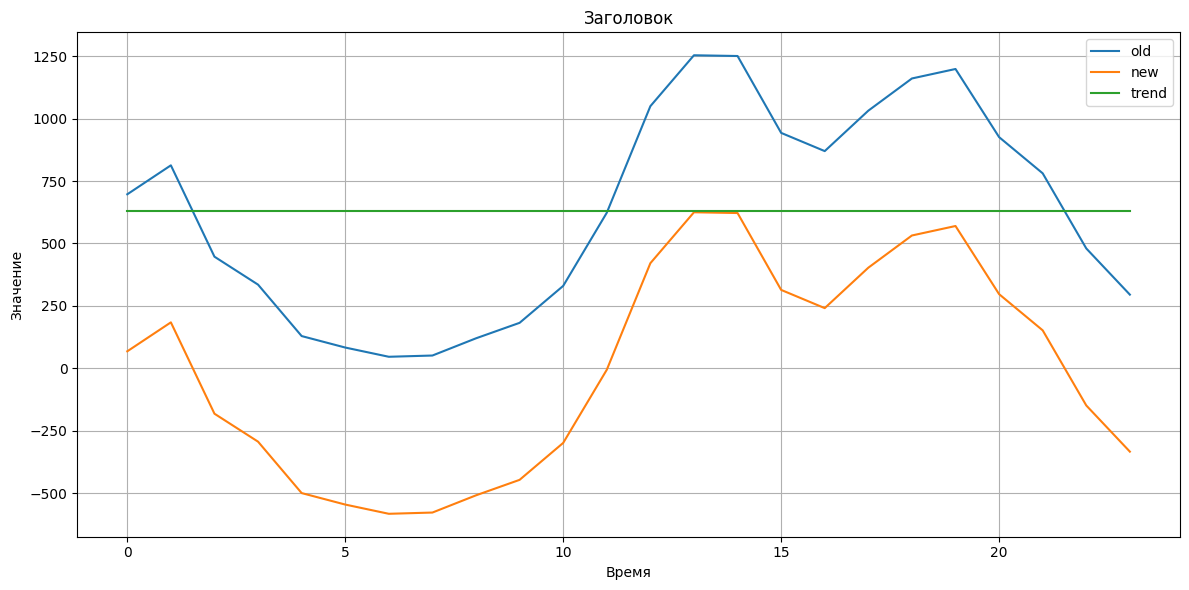

In [5]:
for item in X_train:
    print(item)
    for dim in item:
        print(dim)
        new_dim = tsa_detrend(dim, 0)
        trend = dim - new_dim
        print(new_dim)
        plot_series([dim, new_dim, trend], ['old','new', 'trend'])
        break
    break

In [ ]:
mlflow.set_tracking_uri('http://127.0.0.1:5000/')
mlflow.set_experiment('first experiment1')

2025/06/03 15:01:19 INFO mlflow.tracking.fluent: Experiment with name 'first experiment1' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/ilia_linux/autolabeling_time_series_data/mlruns/826868379125037980', creation_time=1748952079524, experiment_id='826868379125037980', last_update_time=1748952079524, lifecycle_stage='active', name='first experiment1', tags={}>

In [8]:
experiment_name = "first experiment1"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

experiment_id

'266228783312683857'

In [12]:
with mlflow.start_run(experiment_id=experiment_id) as run:
    X_train, X_test, y_train, y_test = prepare_data('Chinatown')

    model = DBSCAN_model()
    model_params = model.default_params
    
    scorer = Clustering_scorer()

    y_pred, trained_model = model.fit_predict(X_train)
    metrics = scorer.evaluate_metrics(y_train, y_pred, X_train)

    print(metrics)
    mlflow.log_metrics(metrics)
    
    # Сохранение модели
    mlflow.sklearn.log_model(model, "model", input_example=X_train[:0])

    print(f"Run ID: {run.info.run_id}")

Old Classes: [1 2]
New Classes: [0 1]
(290, 24) (73, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64
{'n_clusters': 1, 'silhouette': None, 'calinski_harabasz_score': None, 'davies_bouldin_score': None, 'nmi': 0.0, 'ari': 0.0, 'accuracy': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


MlflowException: Missing value for required parameter 'metrics[1].value'.

[[ 697.  813.  447.  335.  129.   83.   46.   51.  120.  182.  330.  623.
  1050. 1254. 1251.  943.  870. 1032. 1161. 1199.  926.  781.  480.  295.]]
[ 697.  813.  447.  335.  129.   83.   46.   51.  120.  182.  330.  623.
 1050. 1254. 1251.  943.  870. 1032. 1161. 1199.  926.  781.  480.  295.]
[  67.91666667  183.91666667 -182.08333333 -294.08333333 -500.08333333
 -546.08333333 -583.08333333 -578.08333333 -509.08333333 -447.08333333
 -299.08333333   -6.08333333  420.91666667  624.91666667  621.91666667
  313.91666667  240.91666667  402.91666667  531.91666667  569.91666667
  296.91666667  151.91666667 -149.08333333 -334.08333333]


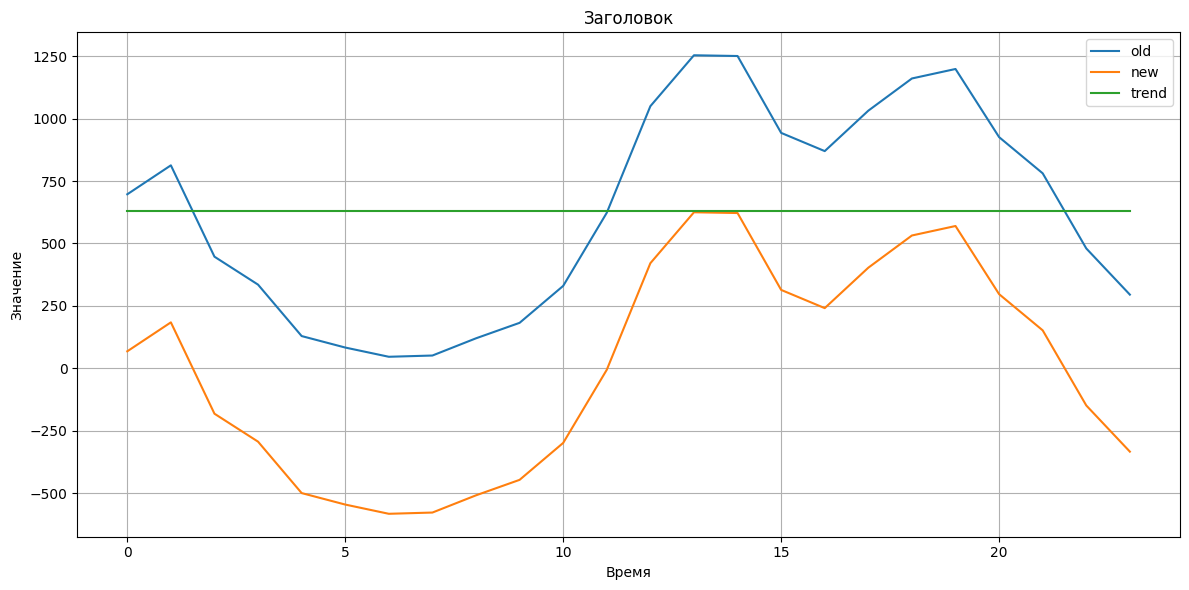

In [ ]:
for item in X_train:
    print(item)
    for dim in item:
        print(dim)
        new_dim = tsa_detrend(dim, 0)
        trend = dim - new_dim
        print(new_dim)
        plot_series([dim, new_dim, trend], ['old','new', 'trend'])
        break
    break

# stage 2

In [ ]:
# "Chinatown" "MelbournePedestrian" "EthanolLevel" "BasicMotions" "ShapeletSim"

In [59]:
from src.app.main import load_data

X_train, X_test, y_train, y_test = load_data("EthanolLevel", 0.7, 'UCR', 'manual', 42)

X_train.shape

Old Classes: [1 2 3 4]
New Classes: [0 1 2 3]


(702, 1, 1751)

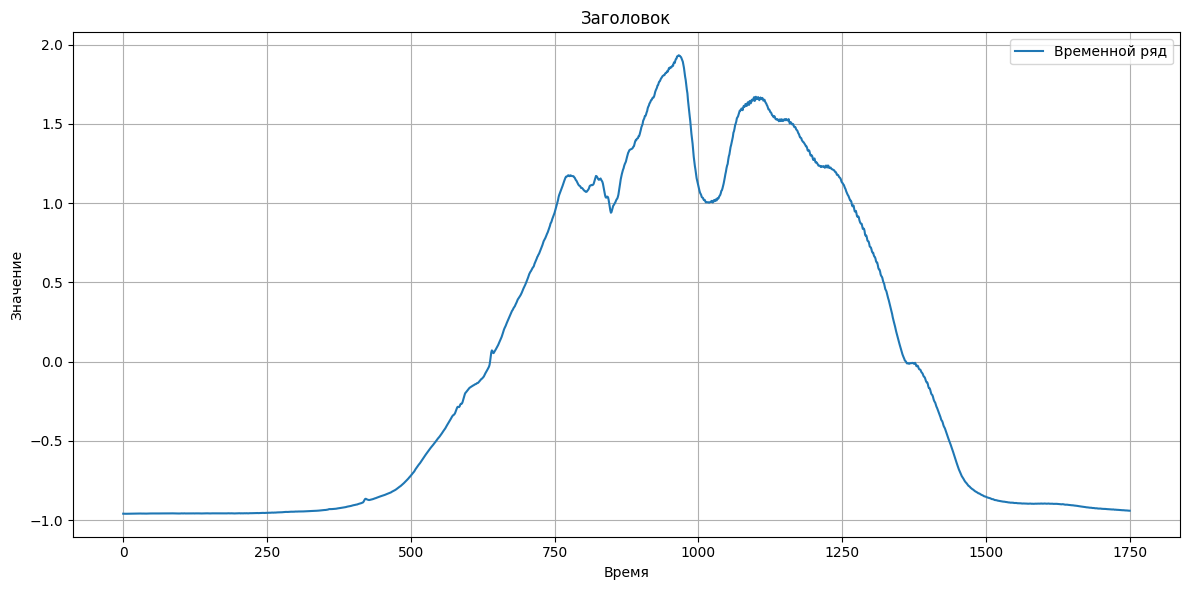

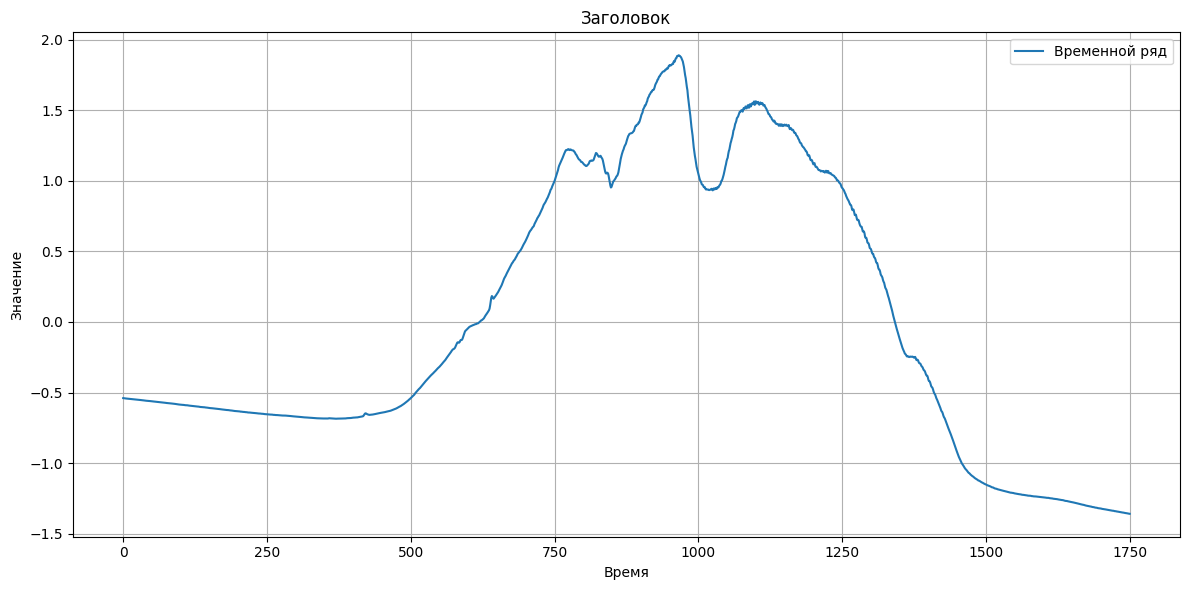

[ 3.81600e+01  2.72000e+00  4.58700e+01  3.06000e+00  5.32700e+01
 -1.87000e+00  5.93800e+01  1.09000e+00  6.42900e+01  5.90000e-01
  6.63000e+01 -2.13000e+00  1.04340e+02  1.18000e+00  1.11720e+02
 -1.00000e+00  3.19090e+02 -1.03000e+00  1.17641e+03  2.68000e+00]


In [ ]:
plot_series(X_train[4][0])
plot_series(tsa_detrend(X_train[4][0], order=1))
# print(signal_peaks_features(X_train[4][0]))
# plot_series()
print(np.round(dft_components(X_train[4][0], 10, 500), 2))

In [ ]:

mlflow.set_tracking_uri('http://127.0.0.1:5000/')
mlflow.set_experiment('experiment_3manual')

experiment_name = "experiment_3manual"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

experiment_id

'185283414451751113'

In [104]:

model = BIRCH_model()
model_params = model.default_params
model_params

{'threshold': 0.5,
 'branching_factor': 50,
 'n_clusters': None,
 'compute_labels': True,
 'copy': False}

In [117]:
from itertools import product
import time 
[item for item in product([0.01, 10, 50], [10, 30, 50, 100], [None, 2, 5, 7])][0]



(0.01, 10, None)

In [122]:
mlflow.set_experiment('experiment_no_fe')

experiment_name = "experiment_no_fe"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

experiment_id

X_train, X_test, y_train, y_test = prepare_data('Chinatown')
model = BIRCH_model()

for threshold, branching_factor, n_clusters in [item for item in product([0.01, 10, 50], [10, 30, 50, 100], [None, 2, 5, 7])]:

    with mlflow.start_run(experiment_id=experiment_id, run_name=f"model_{threshold}_ {branching_factor}_{n_clusters}") as run:
        # parameters setting
        model_params = model.default_params
        model_params['threshold'] = threshold
        mlflow.log_param('threshold', model_params['threshold'])
        model_params['branching_factor'] = branching_factor
        mlflow.log_param('branching_factor', model_params['branching_factor'])
        model_params['n_clusters'] = n_clusters
        mlflow.log_param('n_clusters', model_params['n_clusters'] if model_params['n_clusters'] is not None else 0)
        scorer_time = time.time()
        # scorer 
        scorer = Clustering_scorer()
        # prediction
        y_pred, trained_model = model.fit_predict(X_train)
        end_time = time.time()
        execution_time = end_time - scorer_time
        mlflow.log_param('scorer_prediction', execution_time)
        # evaluating
        metrics_time = time.time()
        metrics = scorer.evaluate_metrics(y_train, y_pred, X_train)
        metrics = {k: v if v is not None else 0 for k, v in metrics.items()}
        mlflow.log_metrics(metrics)
        end_time = time.time()
        execution_time = end_time - metrics_time
        mlflow.log_param('metrics_time', execution_time)


2025/06/03 17:23:51 INFO mlflow.tracking.fluent: Experiment with name 'experiment_no_fe' does not exist. Creating a new experiment.


Old Classes: [1 2]
New Classes: [0 1]
(290, 24) (73, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64
🏃 View run model_0.01_ 10_None at: http://127.0.0.1:5000/#/experiments/533562483560351947/runs/ddd3ac9ffd184cc29d0a63b64f421227
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/533562483560351947
🏃 View run model_0.01_ 10_2 at: http://127.0.0.1:5000/#/experiments/533562483560351947/runs/2ab42625ad4f429ea55291bbb1547cd1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/533562483560351947
🏃 View run model_0.01_ 10_5 at: http://127.0.0.1:5000/#/experiments/533562483560351947/runs/10c78afc125641d49a1ec93f5fcb417b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/533562483560351947
🏃 View run model_0.01_ 10_7 at: http://127.0.0.1:5000/#/experiments/533562483560351947/runs/138f5caf04104d8fa55ea7e6775f9264
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/533562483560351947
🏃 Vi

In [126]:
# kmeans
mlflow.set_experiment('experiment_no_fe_kmeans')

experiment_name = "experiment_no_fe_kmeans"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

experiment_id

X_train, X_test, y_train, y_test = prepare_data('Chinatown')
model = Sklearn_kmeans_model()

for n_init, init, n_clusters in [item for item in product([5, 25, 50], ["k-means++", "random"], [2, 5, 7])]:

    with mlflow.start_run(experiment_id=experiment_id, run_name=f"model_{threshold}_ {branching_factor}_{n_clusters}") as run:
        # parameters setting
        model_params = model.default_params
        model_params['init'] = init
        mlflow.log_param('init', model_params['init'])
        model_params['n_init'] = n_init
        mlflow.log_param('n_init', model_params['n_init'])
        model_params['n_clusters'] = n_clusters
        mlflow.log_param('n_clusters', model_params['n_clusters'] if model_params['n_clusters'] is not None else 0)
        scorer_time = time.time()
        # scorer 
        scorer = Clustering_scorer()
        # prediction
        y_pred, trained_model = model.fit_predict(X_train)
        end_time = time.time()
        execution_time = end_time - scorer_time
        mlflow.log_param('scorer_prediction', execution_time)
        # evaluating
        metrics_time = time.time()
        metrics = scorer.evaluate_metrics(y_train, y_pred, X_train)
        metrics = {k: v if v is not None else 0 for k, v in metrics.items()}
        mlflow.log_metrics(metrics)
        end_time = time.time()
        execution_time = end_time - metrics_time
        mlflow.log_param('metrics_time', execution_time)


2025/06/03 18:03:59 INFO mlflow.tracking.fluent: Experiment with name 'experiment_no_fe_kmeans' does not exist. Creating a new experiment.


Old Classes: [1 2]
New Classes: [0 1]
(290, 24) (73, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64
🏃 View run model_50_ 100_2 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/d52197fead4d4c9ea26e2726d9e96ffe
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run model_50_ 100_5 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/bd20f3df424e482cafcdb3a033a0b8cc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run model_50_ 100_7 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/249a82af23ea4258a1294ab60fa61631
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run model_50_ 100_2 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/9ab59e60463544759467d59dd1a8fe08
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run 

In [ ]:
# dbscan
mlflow.set_experiment('experiment_no_fe_kmeans')

experiment_name = "experiment_no_fe_kmeans"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

experiment_id

X_train, X_test, y_train, y_test = prepare_data('Chinatown')
model = Sklearn_kmeans_model()

for n_init, init, n_clusters in [item for item in product([5, 25, 50], ["k-means++", "random"], [2, 5, 7])]:

    with mlflow.start_run(experiment_id=experiment_id, run_name=f"model_{threshold}_ {branching_factor}_{n_clusters}") as run:
        # parameters setting
        model_params = model.default_params
        model_params['init'] = init
        mlflow.log_param('init', model_params['init'])
        model_params['n_init'] = n_init
        mlflow.log_param('n_init', model_params['n_init'])
        model_params['n_clusters'] = n_clusters
        mlflow.log_param('n_clusters', model_params['n_clusters'] if model_params['n_clusters'] is not None else 0)
        scorer_time = time.time()
        # scorer 
        scorer = Clustering_scorer()
        # prediction
        y_pred, trained_model = model.fit_predict(X_train)
        end_time = time.time()
        execution_time = end_time - scorer_time
        mlflow.log_param('scorer_prediction', execution_time)
        # evaluating
        metrics_time = time.time()
        metrics = scorer.evaluate_metrics(y_train, y_pred, X_train)
        metrics = {k: v if v is not None else 0 for k, v in metrics.items()}
        mlflow.log_metrics(metrics)
        end_time = time.time()
        execution_time = end_time - metrics_time
        mlflow.log_param('metrics_time', execution_time)


2025/06/03 18:03:59 INFO mlflow.tracking.fluent: Experiment with name 'experiment_no_fe_kmeans' does not exist. Creating a new experiment.


Old Classes: [1 2]
New Classes: [0 1]
(290, 24) (73, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64
🏃 View run model_50_ 100_2 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/d52197fead4d4c9ea26e2726d9e96ffe
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run model_50_ 100_5 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/bd20f3df424e482cafcdb3a033a0b8cc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run model_50_ 100_7 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/249a82af23ea4258a1294ab60fa61631
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run model_50_ 100_2 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/9ab59e60463544759467d59dd1a8fe08
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run 

In [ ]:
# agglo
mlflow.set_experiment('experiment_no_fe_kmeans')

experiment_name = "experiment_no_fe_kmeans"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

experiment_id

X_train, X_test, y_train, y_test = prepare_data('Chinatown')
model = Sklearn_kmeans_model()

for n_init, init, n_clusters in [item for item in product([5, 25, 50], ["k-means++", "random"], [2, 5, 7])]:

    with mlflow.start_run(experiment_id=experiment_id, run_name=f"model_{threshold}_ {branching_factor}_{n_clusters}") as run:
        # parameters setting
        model_params = model.default_params
        model_params['init'] = init
        mlflow.log_param('init', model_params['init'])
        model_params['n_init'] = n_init
        mlflow.log_param('n_init', model_params['n_init'])
        model_params['n_clusters'] = n_clusters
        mlflow.log_param('n_clusters', model_params['n_clusters'] if model_params['n_clusters'] is not None else 0)
        scorer_time = time.time()
        # scorer 
        scorer = Clustering_scorer()
        # prediction
        y_pred, trained_model = model.fit_predict(X_train)
        end_time = time.time()
        execution_time = end_time - scorer_time
        mlflow.log_param('scorer_prediction', execution_time)
        # evaluating
        metrics_time = time.time()
        metrics = scorer.evaluate_metrics(y_train, y_pred, X_train)
        metrics = {k: v if v is not None else 0 for k, v in metrics.items()}
        mlflow.log_metrics(metrics)
        end_time = time.time()
        execution_time = end_time - metrics_time
        mlflow.log_param('metrics_time', execution_time)


2025/06/03 18:03:59 INFO mlflow.tracking.fluent: Experiment with name 'experiment_no_fe_kmeans' does not exist. Creating a new experiment.


Old Classes: [1 2]
New Classes: [0 1]
(290, 24) (73, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64
🏃 View run model_50_ 100_2 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/d52197fead4d4c9ea26e2726d9e96ffe
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run model_50_ 100_5 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/bd20f3df424e482cafcdb3a033a0b8cc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run model_50_ 100_7 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/249a82af23ea4258a1294ab60fa61631
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run model_50_ 100_2 at: http://127.0.0.1:5000/#/experiments/550404222996516589/runs/9ab59e60463544759467d59dd1a8fe08
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/550404222996516589
🏃 View run 

In [125]:
mlflow.set_experiment('experiment_detrend')

experiment_name = "experiment_detrend"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

experiment_id

X_train, X_test, y_train, y_test = prepare_data('Chinatown')
model = BIRCH_model()
print(X_train.shape)

for order in [0,1,2]:

    for threshold, branching_factor, n_clusters in [item for item in product([0.01, 10, 50], [10, 30, 50, 100], [None, 2, 5, 7])]:

        with mlflow.start_run(experiment_id=experiment_id, run_name=f"model_{threshold}_ {branching_factor}_{n_clusters}") as run:
            # fe 
            mlflow.log_param('order', order)
            fe_time = time.time()
            X_train_new = np.array([tsa_detrend(row, order) for row in X_train])
            end_time = time.time()
            execution_time = end_time - fe_time
            mlflow.log_param('fe_time', execution_time)
            # clustering parameters setting
            model_params = model.default_params
            model_params['threshold'] = threshold
            mlflow.log_param('threshold', model_params['threshold'])
            model_params['branching_factor'] = branching_factor
            mlflow.log_param('branching_factor', model_params['branching_factor'])
            model_params['n_clusters'] = n_clusters
            mlflow.log_param('n_clusters', model_params['n_clusters'] if model_params['n_clusters'] is not None else 0)
            scorer_time = time.time()
            # scorer 
            scorer = Clustering_scorer()
            # prediction
            y_pred, trained_model = model.fit_predict(X_train_new)
            end_time = time.time()
            execution_time = end_time - scorer_time
            mlflow.log_param('scorer_prediction', execution_time)
            # evaluating
            metrics_time = time.time()
            metrics = scorer.evaluate_metrics(y_train, y_pred, X_train_new)
            metrics = {k: v if v is not None else 0 for k, v in metrics.items()}
            mlflow.log_metrics(metrics)
            end_time = time.time()
            execution_time = end_time - metrics_time
            mlflow.log_param('metrics_time', execution_time)


Old Classes: [1 2]
New Classes: [0 1]
(290, 24) (73, 24)
[0 1]
1    0.713793
0    0.286207
Name: proportion, dtype: float64
1    0.712329
0    0.287671
Name: proportion, dtype: float64
(290, 24)
🏃 View run model_0.01_ 10_None at: http://127.0.0.1:5000/#/experiments/739358259265598734/runs/acf58f77264e421393158e11116ce8eb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/739358259265598734
🏃 View run model_0.01_ 10_2 at: http://127.0.0.1:5000/#/experiments/739358259265598734/runs/5d50671866dc479eb2d85896c03358e3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/739358259265598734
🏃 View run model_0.01_ 10_5 at: http://127.0.0.1:5000/#/experiments/739358259265598734/runs/d564203f2ca44958ac73ecdabb6caca0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/739358259265598734
🏃 View run model_0.01_ 10_7 at: http://127.0.0.1:5000/#/experiments/739358259265598734/runs/3ee03429ddb34765913db00a168000b8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7393582592655

# stage 3

## data generation | data collecting

{'slope_d': 0.1, 'slope_u': 0.8, 'slope_q': 10, 'length': 101}


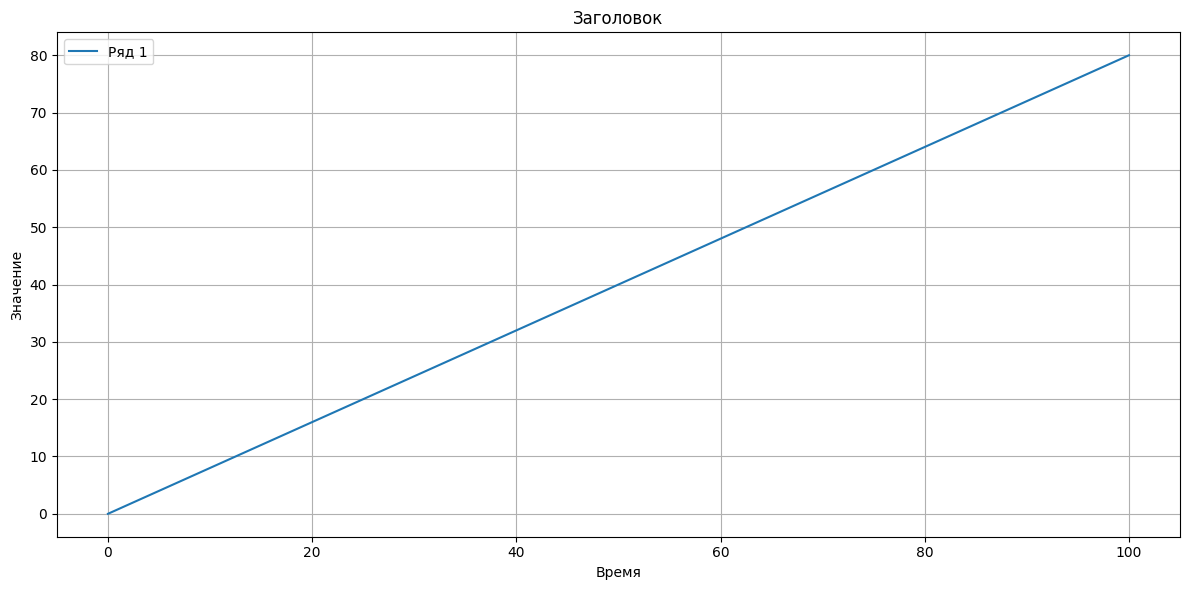

In [14]:
lin_gen = TS_generator(linear_trend, 'configs/trends/basic_linear_trend.yaml')
print(lin_gen.config)
lin_gen.config['slope_d'] = 0.8
lin_gen.config['slope_u'] = 0.8
lin_gen.config['slope_q'] = 1
# lin_gen.config['length'] = 
trend_series1 = lin_gen.generate()[0]
plot_series(trend_series1)

{'a_d': 0.001, 'a_u': 0.009, 'a_q': 10, 'b_d': 0, 'b_u': 0, 'b_q': 1, 'c_d': 0, 'c_u': 0, 'c_q': 1, 'length': 101}


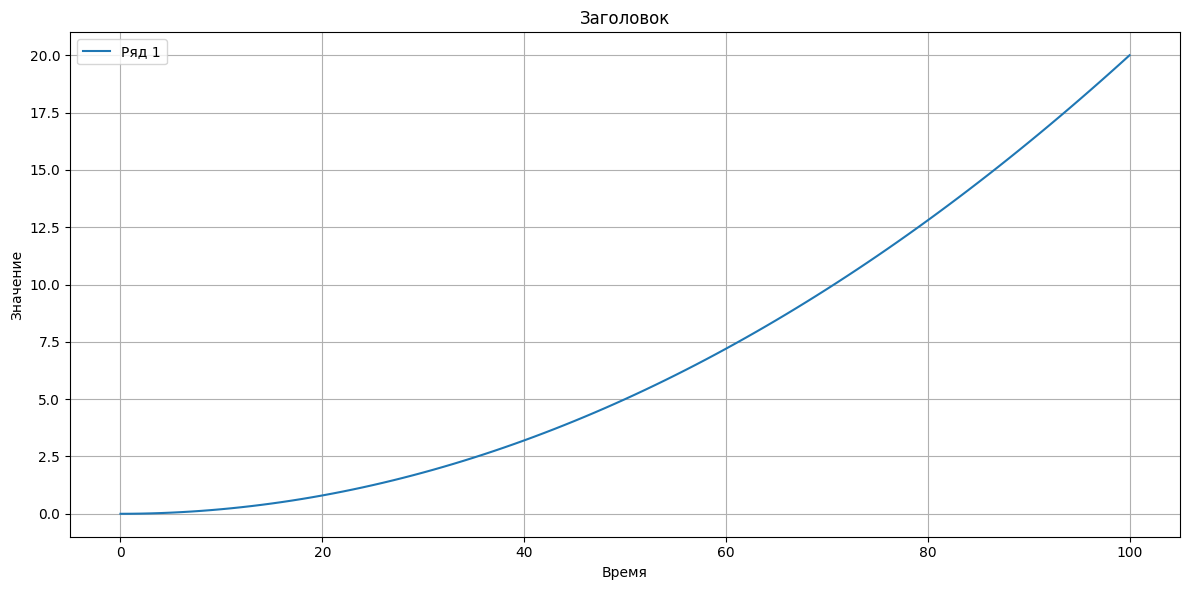

In [15]:
quad_gen = TS_generator(quadratic_trend, 'configs/trends/basic_quadratic_trend.yaml')
print(quad_gen.config)
# quad_gen.config['a_d'] = 
# quad_gen.config['a_u'] = 
# quad_gen.config['a_q'] = 
# quad_gen.config['length'] = 
trend_series2 = quad_gen.generate()[0]
plot_series(trend_series2)

{'alpha_d': 0.02, 'alpha_u': 0.04, 'alpha_q': 10, 'length': 101}


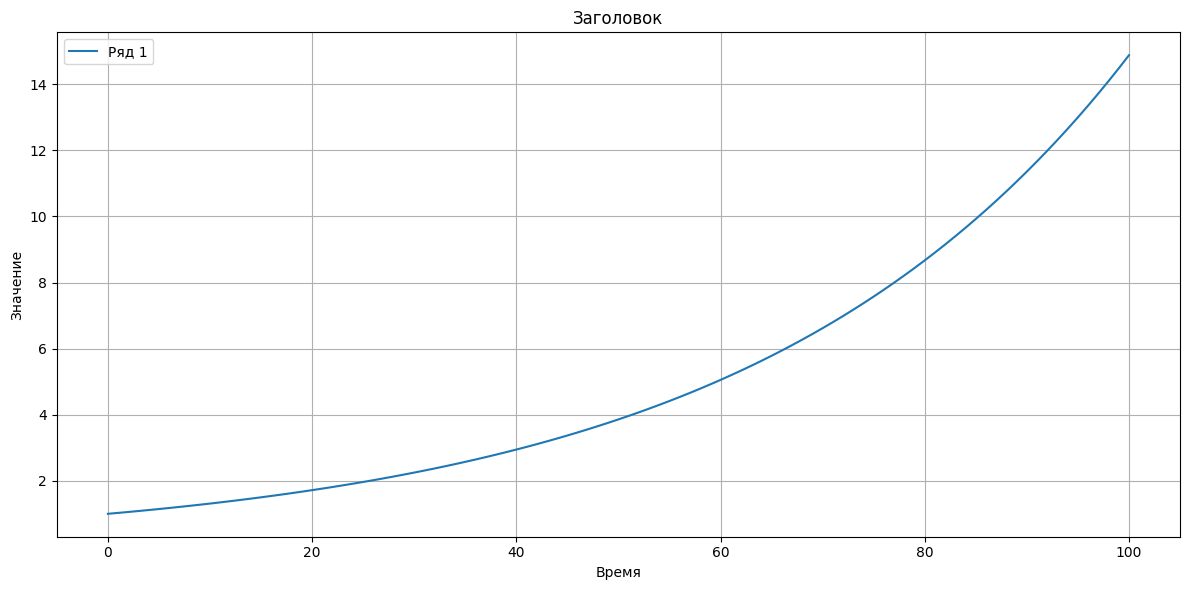

In [16]:
exp_gen = TS_generator(exponential_trend, 'configs/trends/basic_exponential_trend.yaml')
print(exp_gen.config)
# exp_gen.config['alpha_d'] = 
# exp_gen.config['alpha_u'] = 
# exp_gen.config['alpha_q'] = 
# exp_gen.config['length'] = 
trend_series3 = exp_gen.generate()[0]
plot_series(trend_series3)

{'amplitude_d': 80, 'amplitude_u': 100, 'amplitude_q': 1, 'frequency_d': 2, 'frequency_u': 4, 'frequency_q': 2, 'phase_d': 0.0, 'phase_u': 0, 'phase_q': 1, 'length': 101}


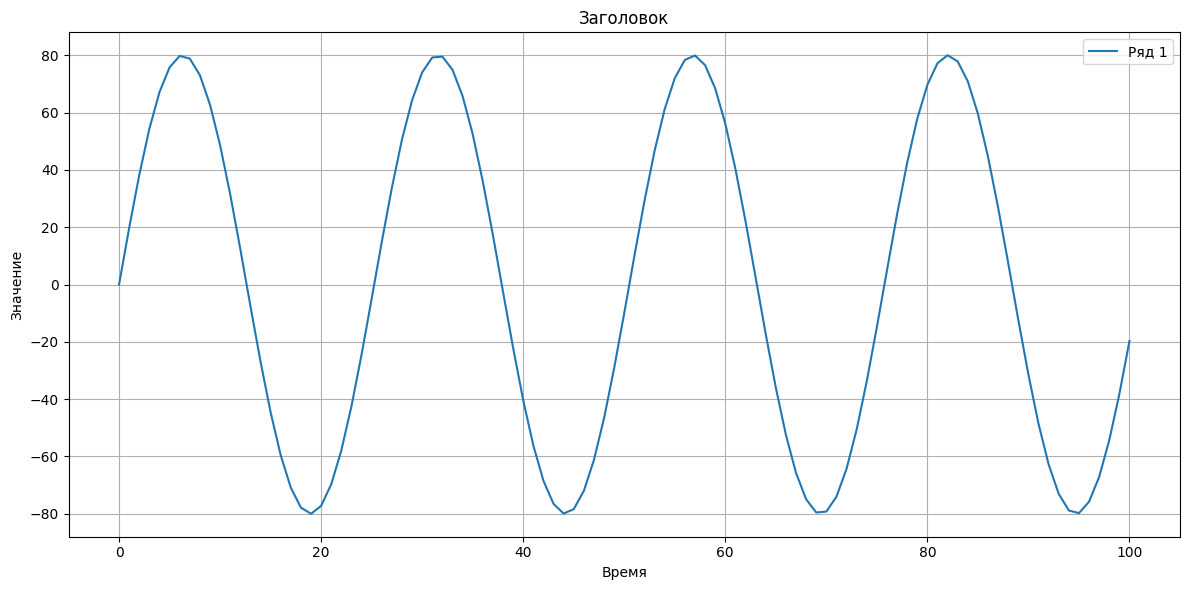

In [17]:
sin_gen = TS_generator(sin_wave, 'configs/seasonality/basic_sin_wave.yaml')
print(sin_gen.config)
# sin_gen.config['frequency_d'] = 
# sin_gen.config['frequency_u'] = 
# sin_gen.config['frequency_q'] = 
# sin_gen.config['length'] = 
seas_series1 = sin_gen.generate()[0]
plot_series(seas_series1)

{'amplitude_d': 80, 'amplitude_u': 100, 'amplitude_q': 1, 'frequency_d': 3, 'frequency_u': 8, 'frequency_q': 5, 'phase_d': 0, 'phase_u': 0, 'phase_q': 1, 'length': 101}


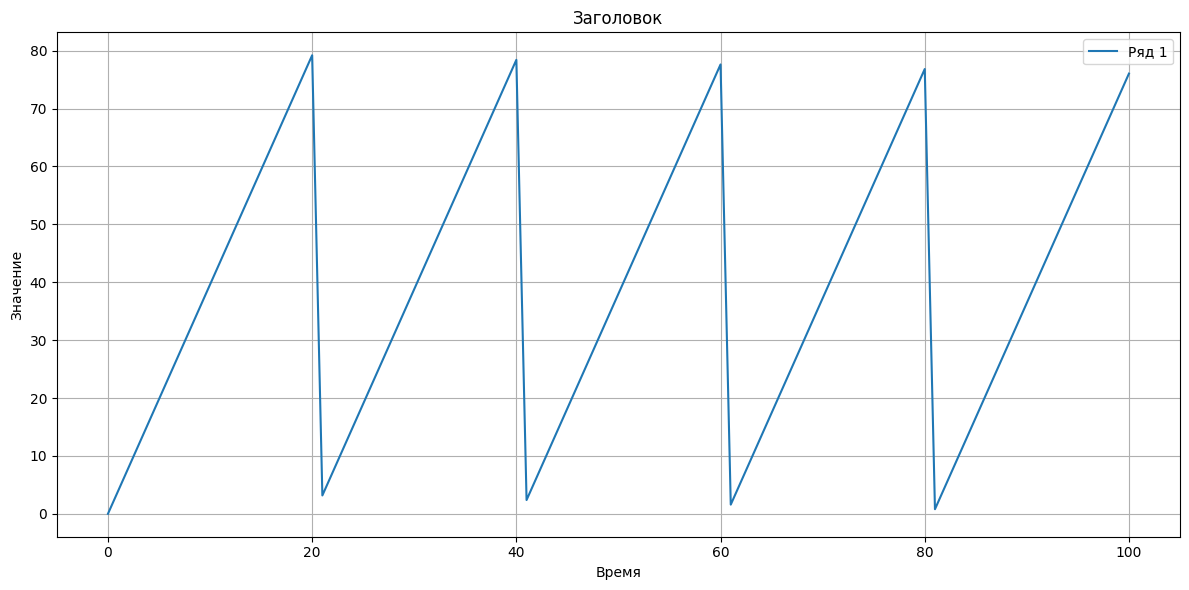

In [18]:
saw_gen = TS_generator(sawtooth_wave, 'configs/seasonality/basic_saw_wave.yaml')
print(saw_gen.config)
saw_gen.config['frequency_d'] = 5
saw_gen.config['frequency_u'] = 5
saw_gen.config['frequency_q'] = 1
# saw_gen.config['length'] = 
seas_series2 = saw_gen.generate()[0]
plot_series(seas_series2)

Old Classes: [1 2]
New Classes: [0 1]


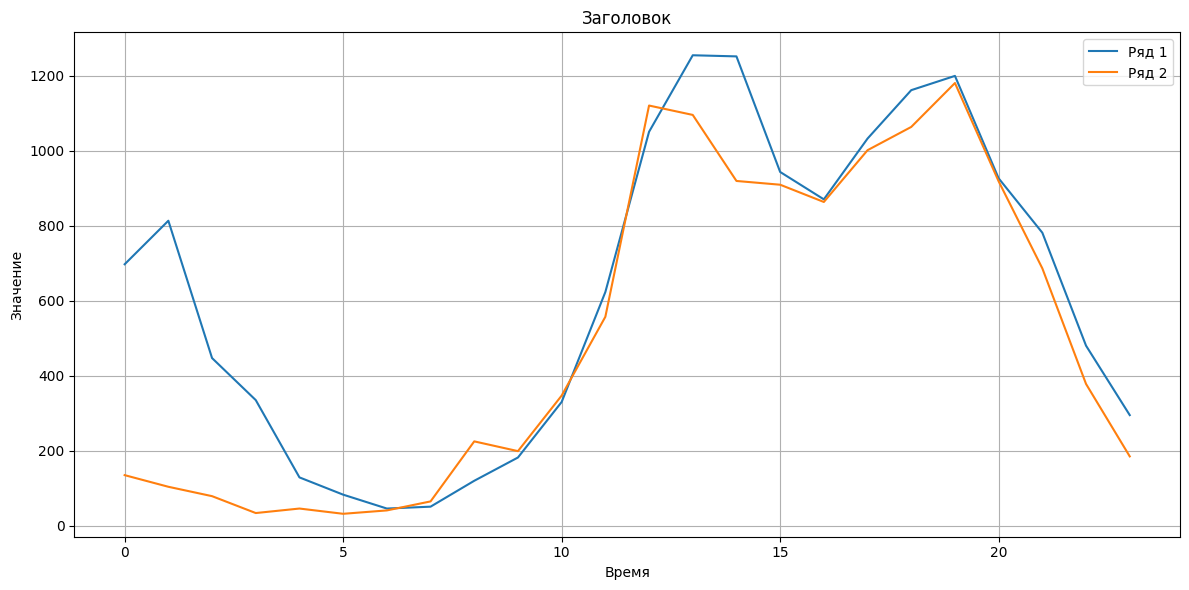

In [19]:
X_train, X_test, y_train, y_test = load_data('Chinatown', 0.7, 'UCR', 'manual', 42)

real_series11 = X_train[0][0]
real_series12 = X_train[2][0]
plot_series([real_series11,real_series12])

Old Classes: [1 2 3 4]
New Classes: [0 1 2 3]


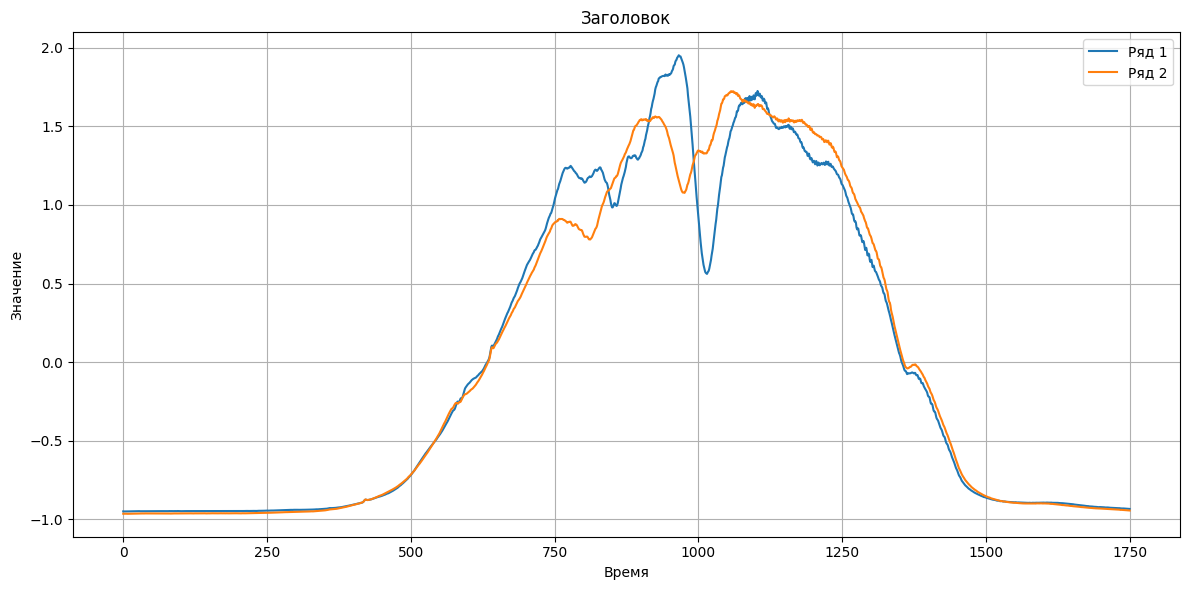

In [ ]:
X_train, X_test, y_train, y_test = load_data('EthanolLevel', 0.7, 'UCR', 'manual', 42)

real_series21 = X_train[0][0]
real_series22 = X_train[7][0]
plot_series([real_series21,real_series22])

In [100]:
X_train, X_test, y_train, y_test = load_data('MelbournePedestrian', 0.7, 'UCR', 'manual', 42)
# X_train, X_test, y_train, y_test = load_data('Chinatown', 0.8, 'UCR', 'manual', 42)

X_train = X_train.squeeze(1)

Old Classes: [ 1  2  3  4  5  6  7  8  9 10]
New Classes: [0 1 2 3 4 5 6 7 8 9]


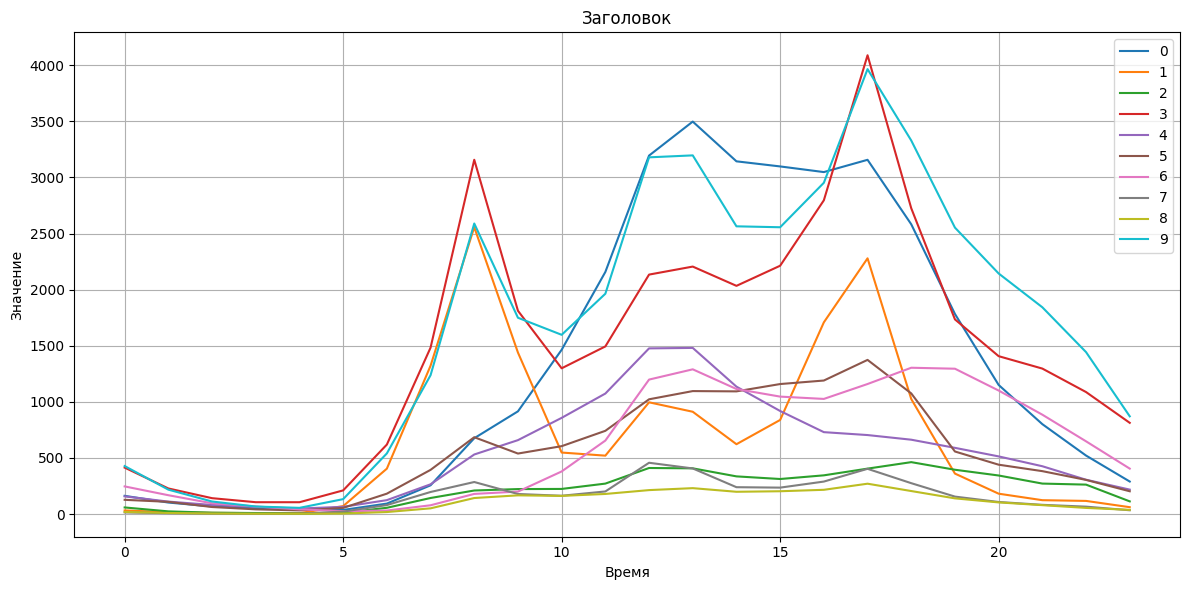

In [74]:
# plot_series([X_train[y_train == 3][0],X_train[y_train == 1][0]])
# X_train[y_train == 3].shape, X_train[y_train == 1].shape
# plot_series([item for item in X_train[y_train == 2][:12]], show_legend=False)
# plot_series([item for item in X_train[y_train == 3][7:9]], show_legend=False)
# plot_series([item for item in X_train[y_train == 7][10:50]], show_legend=False)
# plot_series([item for item in X_train[y_train == 8][10:50]], show_legend=False)
from src.utils import plot_series

# X_train_transf = np.array([show_tsa_detrend([item,np.zeros(item.shape)], 1)[0] for item in X_train[:5]]) 

ils = []
fl = []
for il in np.unique(y_train):
    # plot_series(np.mean([item for item in X_train[y_train == il]], axis=0), show_legend=False)
    fl.append(np.mean([item for item in X_train[y_train == il]], axis=0))
    # fl.append(np.mean([item for item in X_train_transf[y_train[:5] == il]], axis=0))
    ils.append(il)

# print(len(fl))
plot_series([item for item in fl], ils)
# plot_series([fl[0]], [0], colors=['#FFA500'])
# plot_series([fl[0][:12], fl[5][:12], fl[0][12:], fl[5][12:]], [0, 5, 0, 5], colors=['#FFA500', "#A0772A", '#FFA500', "#A0772A"])
# plot_series([fl[3][:10], fl[9][:9], fl[3][9:16], fl[9][9:16]], [3, 9, 3, 9], colors=["#FF0000", "#B0EBFD", "#FF0000", "#B0EBFD",])
# plot_series([fl[1], fl[8]], [1, 6])


# plot_series([fl[2],fl[7],fl[8]], [ils[2], ils[7],ils[8]], ['#556B2F' ,'gray', '#CC9933'])
# plot_series([fl[0],fl[1]], [ils[0], ils[1]], ['red' ,"#2CBAE9"])

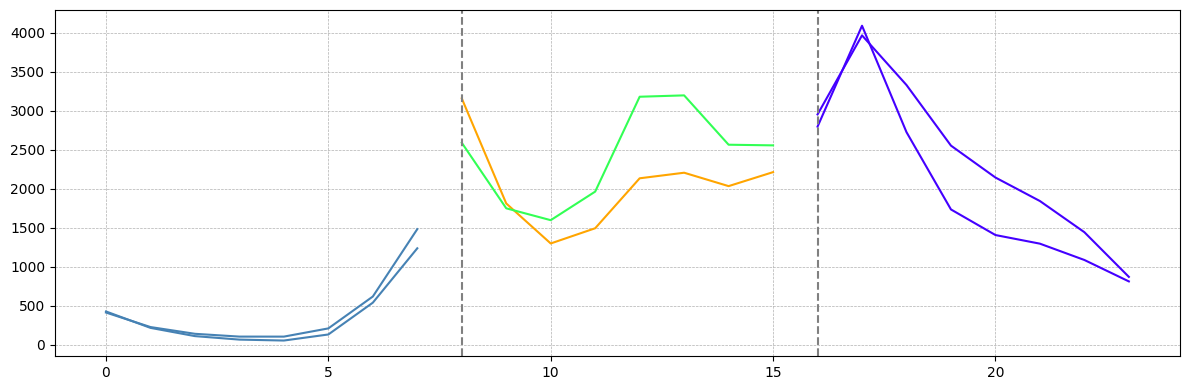

In [124]:
def show_segments2(ts_row1, ts_row2, ts_row3, ts_row4, ts_row5):
    """
    Отображает три временных ряда как единое целое с разделением между сегментами.
    
    Параметры:
        ts_row1, ts_row2, ts_row3: массивы или списки - детрендированные временные ряды.
    """
    # Создаем ось X для каждого сегмента, чтобы они шли друг за другом
    x1 = np.arange(len(ts_row1[0]))  # [0, 1, ..., len(ts_row1) - 1]
    x2 = np.arange(len(ts_row1[0]), len(ts_row1[0]) + len(ts_row2[0]))
    x3 = np.arange(len(ts_row1[0]) + len(ts_row2[0]), 
                   len(ts_row1[0]) + len(ts_row2[0]) + len(ts_row3[0]))
    x4 = np.arange(len(ts_row1[0]) + len(ts_row2[0]) + len(ts_row3[0]), 
                   len(ts_row1[0]) + len(ts_row2[0]) + len(ts_row3[0]) + len(ts_row4[0]))
    x5 = np.arange(len(ts_row1[0]) + len(ts_row2[0]) + len(ts_row3[0]) + len(ts_row4[0]),
                len(ts_row1[0]) + len(ts_row2[0]) + len(ts_row3[0]) + len(ts_row4[0]) + len(ts_row5[0])   )

    # Строим график
    plt.figure(figsize=(12, 4))

    # Рисуем каждый сегмент отдельно
    plt.plot(x1, ts_row1[0], color="#E6FA36")
    plt.plot(x1, ts_row1[1], color="#E6FA36")
    plt.plot(x2, ts_row2[0], color="#FD0800")
    plt.plot(x2, ts_row2[1], color="#FD0800") # color="#0060B9"
    plt.plot(x3, ts_row3[0], color="#FFBB3D")
    plt.plot(x3, ts_row3[1], color="#FFBB3D")
    plt.plot(x4, ts_row4[0], color="#8AFFFF")
    plt.plot(x4, ts_row4[1], color="#8AFFFF")
    plt.plot(x5, ts_row5[0], color="#FF8AEF")
    plt.plot(x5, ts_row5[1], color="#FF8AEF")
    
    # Добавляем вертикальные пунктирные линии между сегментами
    plt.axvline(5, color='gray', linestyle='--', linewidth=1.5)
    plt.axvline(10, color='gray', linestyle='--', linewidth=1.5)
    plt.axvline(15, color='gray', linestyle='--', linewidth=1.5)
    plt.axvline(20, color='gray', linestyle='--', linewidth=1.5)
    
    # Оформление графика
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

def show_segments4(ts_row1, ts_row2, ts_row3):
    """
    Отображает три временных ряда как единое целое с разделением между сегментами.
    
    Параметры:
        ts_row1, ts_row2, ts_row3: массивы или списки - детрендированные временные ряды.
    """
    # Создаем ось X для каждого сегмента, чтобы они шли друг за другом
    x1 = np.arange(len(ts_row1[0]))  # [0, 1, ..., len(ts_row1) - 1]
    x2 = np.arange(len(ts_row1[0]), len(ts_row1[0]) + len(ts_row2[0]))
    x3 = np.arange(len(ts_row1[0]) + len(ts_row2[0]), 
                   len(ts_row1[0]) + len(ts_row2[0]) + len(ts_row3[0]))

    # Строим график
    plt.figure(figsize=(12, 4))

    # # Рисуем каждый сегмент отдельно
    # plt.plot(x1, ts_row1[0], color='#4682B4')
    # plt.plot(x1, ts_row1[1], color='#4682B4')
    # plt.plot(x2, ts_row2[0], color='#FFA500')
    # plt.plot(x2, ts_row2[1], color='#4682B4')
    # plt.plot(x3, ts_row3[0], color='#FFA500')
    # plt.plot(x3, ts_row3[1], color='#FFA500')
    plt.plot(x1, ts_row1[0], color='#4682B4')
    plt.plot(x1, ts_row1[1], color='#4682B4')
    plt.plot(x2, ts_row2[0], color='#FFA500')
    plt.plot(x2, ts_row2[1], color="#32FF54")
    plt.plot(x3, ts_row3[0], color="#4400FF")
    plt.plot(x3, ts_row3[1], color="#4400FF")
    
    # Добавляем вертикальные пунктирные линии между сегментами
    plt.axvline(8, color='gray', linestyle='--', linewidth=1.5)
    plt.axvline(16, color='gray', linestyle='--', linewidth=1.5)

    # Оформление графика
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

row1 = fl[3]
row2 = fl[9]

show_segments4([row1[:8], row2[:8]], [row1[8:16], row2[8:16]], [row1[16:], row2[16:]])

# show_segments2([row1[:5], row2[:5]],[row1[5:10], row2[5:10]], [row1[10:15], row2[10:15]],[row1[15:20], row2[15:20]],[row1[20:], row2[20:]])

# show_segments4([row1[:8] - tsa_detrend(row1[:8]), row2[:8] - tsa_detrend(row2[:8])],[row1[8:16] - tsa_detrend(row1[8:16]), row2[8:16] - tsa_detrend(row2[8:16])], [row1[16:] - tsa_detrend(row1[16:]), row2[16:] - tsa_detrend(row2[16:])])

# show_segments4([row1[:8] - tsa_detrend(row1[:8], 1), row2[:8] - tsa_detrend(row2[:8], 1)],[row1[8:16] - tsa_detrend(row1[8:16], 1), row2[8:16] - tsa_detrend(row2[8:16], 1)], [row1[16:] - tsa_detrend(row1[16:], 1), row2[16:] - tsa_detrend(row2[16:], 1)])

# fs = 100
# comp1, _ = dft_extract(row1, n_freqs=2, fs=fs)
# row11 = dft_aprox(comp1, 8, 8)
# comp2, _ = dft_extract(row2, n_freqs=2, fs=fs)
# row22 = dft_aprox(comp2, 8, 8)

# print(row11)
# show_segments4([row11[:8], row22[:8]], [row11[8:16], row22[8:16]], [row11[16:], row22[16:]])

## fe methods reworked

In [92]:
from itertools import product 

def make_grid_search(params_dict:dict):
    # Получаем все комбинации значений
    keys = params_dict.keys()
    values = [params_dict[key] for key in keys]

    # Создаём комбинации и объединяем с ключами
    param_combinations = [dict(zip(keys, v)) for v in product(*values)]

    return [params for params in param_combinations]


In [93]:
from numpy.fft import fft, ifft, fftfreq


def dft_extract(series, n_freqs=10, fs=500, freq_min=0, freq_max=None):
    
    if not isinstance(n_freqs, int):
        n_freqs = int(n_freqs)

    # Прямое преобразование Фурье
    dft_values = fft(series)
    magnitude = np.abs(dft_values)
    phases = np.angle(dft_values)

    n = len(series)
    freq = fftfreq(n, d=1/fs)

    half_n = n // 2
    positive_freq = freq[:half_n]
    positive_magnitude = magnitude[:half_n]
    positive_phases = phases[:half_n]

    # Применяем фильтр по диапазону частот
    if freq_max is None:
        freq_max = freq[half_n - 1]

    mask = (positive_freq >= freq_min) & (positive_freq <= freq_max)
    masked_freq = positive_freq[mask]
    masked_magnitude = positive_magnitude[mask]
    masked_phases = positive_phases[mask]
    masked_indices = np.where(mask)[0]  # индексы после маски

    # Получаем топ-N самых мощных компонент
    sorted_indices_in_mask = np.argsort(masked_magnitude)[-n_freqs:]
    significant_indices = masked_indices[sorted_indices_in_mask]

    # Сохраняем компоненты
    significant_components = [
        (freq[i], magnitude[i], phases[i]) for i in significant_indices
    ]

    return significant_components, (positive_freq, positive_magnitude)


def dft_plot(significant_components, positive_freq, positive_magnitude, save_path=None):
    plt.figure(figsize=(12, 6))
    plt.plot(positive_freq, positive_magnitude, label='Амплитудный спектр')
    plt.scatter(
        [comp[0] for comp in significant_components],
        [comp[1] for comp in significant_components],
        color='red', label='Выбранные компоненты'
    )
    plt.xlabel('Grequency (Ghz)')
    plt.ylabel('Amplitude')
    plt.title('Furier spectr and chosen significant components')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()


def dft_aprox(components, signal_length, fs=500):
    """
    Восстанавливает временной ряд на основе заданных частотных компонент.

    Параметры:
        components (list): Список кортежей (частота, амплитуда, фаза).
        signal_length (int): Длина выходного сигнала.
        fs (float): Частота дискретизации.

    Возвращает:
        np.ndarray: Восстановленный временной ряд.
    """
    restored_spectrum = np.zeros(signal_length, dtype=complex)

    for freq, amplitude, phase in components:
        # Находим индекс ближайшей частоты в FFT-сетке
        idx = int(round(freq * signal_length / fs))
        if idx >= signal_length // 2 or idx < 0:
            continue  # пропускаем некорректные частоты вне диапазона

        # Заполняем спектр
        restored_spectrum[idx] = amplitude * np.exp(1j * phase)
        restored_spectrum[-idx] = amplitude * np.exp(-1j * phase)

    # Обратное преобразование Фурье
    restored_signal = ifft(restored_spectrum).real
    return restored_signal

dft_grid = {
    'fs': [100, 500, 1000],
    'n_freqs': [1, 5, 10, 20],
    'freq_min': [0],
    'freq_max': [None]
}

dft_grid_search = make_grid_search(dft_grid)
# print(len(dft_grid_search))
print(dft_grid_search)

[{'fs': 100, 'n_freqs': 1, 'freq_min': 0, 'freq_max': None}, {'fs': 100, 'n_freqs': 5, 'freq_min': 0, 'freq_max': None}, {'fs': 100, 'n_freqs': 10, 'freq_min': 0, 'freq_max': None}, {'fs': 100, 'n_freqs': 20, 'freq_min': 0, 'freq_max': None}, {'fs': 500, 'n_freqs': 1, 'freq_min': 0, 'freq_max': None}, {'fs': 500, 'n_freqs': 5, 'freq_min': 0, 'freq_max': None}, {'fs': 500, 'n_freqs': 10, 'freq_min': 0, 'freq_max': None}, {'fs': 500, 'n_freqs': 20, 'freq_min': 0, 'freq_max': None}, {'fs': 1000, 'n_freqs': 1, 'freq_min': 0, 'freq_max': None}, {'fs': 1000, 'n_freqs': 5, 'freq_min': 0, 'freq_max': None}, {'fs': 1000, 'n_freqs': 10, 'freq_min': 0, 'freq_max': None}, {'fs': 1000, 'n_freqs': 20, 'freq_min': 0, 'freq_max': None}]


In [94]:
# detrend + 
# tsa_detrend

def show_tsa_detrend(original, order):
    org_trend, other = original
    detrended = tsa_detrend(org_trend + other, order=order)
    trend = (org_trend + other) - detrended
    
    plot_series([org_trend + other, detrended], ['original', 'detrended'], plot_title='comparison')
    plot_series([org_trend, trend], ['original', 'trend'], plot_title='trend')
   
    return detrended, trend 

detrend_grid = {
    'order':[0,1,2]
}

detrend_grid_search = make_grid_search(detrend_grid)
# print(len(detrend_grid_search))
print(detrend_grid_search)

[{'order': 0}, {'order': 1}, {'order': 2}]


In [96]:
# stl +
from statsmodels.tsa.seasonal import STL

def stl_decomposition(series, period, components:dict={'trend':True, 'seasonality':True, 'residual':False}):
    res = STL(series, period=period).fit()
    return res.trend, res.seasonal, res.resid

stl_grid = {
    'period': [3, 7, 24, 30, 48, 72]
}

stl_grid_search = make_grid_search(stl_grid)
# print(len(stl_grid_search))
print(stl_grid_search)


def show_stl_result(original, period, components={'trend':True, 'seasonality':True, 'residual':True}):
    orig_trend, orig_seas, orig_resid = original
    if orig_resid is None:
        orig_resid = np.zeros(np.max([orig_trend.shape[0], orig_seas.shape[0]]))
    trend, seas, resid = stl_decomposition(orig_trend+orig_seas+orig_resid, period=period, components=components)
    plot_series([orig_trend+orig_seas+orig_resid, seas + trend + resid], ['original', 'decomposed'], plot_title='full')
    plot_series([orig_trend, trend], ['original', 'trend'], plot_title='trend')
    plot_series([orig_seas, seas], ['original','seasonality'], plot_title='seasonality')
    plot_series([orig_resid, resid], ['original','residual'], plot_title='residual')
    
    return trend, seas, resid


[{'period': 3}, {'period': 7}, {'period': 24}, {'period': 30}, {'period': 48}, {'period': 72}]


## Experiments

In [25]:
from sklearn.metrics import mean_squared_error as RMSE

In [25]:
# cluster_scorer=Clustering_scorer()
# cluster_scorer.evaluate_metrics(y_train, labels[0], [scaler.fit_transform(item.reshape(-1, 1)).flatten() for item in X_train.squeeze(1)])

In [26]:
# dft pics
# recon together + freq ampl space + all recon (param) + pics comp: real recon
# detrend pics
# 
# stl pics
# seasonality trend pics + 

In [8]:
X_train, X_test, y_train, y_test = load_data('Chinatown', 0.1, 'UCR', 'manual', 42)
print(X_train.shape, np.unique(y_train))

NameError: name 'load_data' is not defined

In [ ]:
def create_experiment(experiment_name, combined_grid, model_keys, fe_keys, fe_name, X, y):
    mlflow.set_experiment(experiment_name)
    try:
        experiment_id = mlflow.create_experiment(experiment_name)
    except:
        experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id
        
    for inx, params in enumerate(combined_grid):
        run_name = f"run:{inx}"
        try:
            with mlflow.start_run(experiment_id=experiment_id, run_name=run_name) as run:
                
                model_params = {key:value for key, value in params.items() if key in model_keys}
                fe_params = {key:value for key, value in params.items() if key in fe_keys}
                # log params
                for key, value in model_params.items():
                    mlflow.log_param(f"model__{key}", value)
                for key, value in fe_params.items():
                    mlflow.log_param(f"fe__{key}", value)
                
                # fe
                if fe_name == 'detrend':
                    X_fe = np.asarray([tsa_detrend(row, **fe_params) for row in X])
                elif fe_name == 'dft':
                    components = [dft_extract(row, **fe_params)[0] for row in X]
                    pos_comp = [dft_extract(row, **fe_params)[1] for row in X] 
                    X_fe = np.asarray([dft_aprox(row, len(row), fe_params['fs']) for row in components])
                
                elif fe_name == 'stl':
                    X_fe = np.asarray([np.sum(stl_decomposition(seas_series1, **fe_params), axis=0) for row in X]) 
                # eval
                model.default_params = model_params
                y_pred, trained_model = model.fit_predict(X_fe)
                
                scorer = Clustering_scorer()
                metrics = scorer.evaluate_metrics(y, y_pred, X_fe)
                metrics = {k: v if v is not None else 0 for k, v in metrics.items()}
                # log metrics
                mlflow.log_metrics(metrics)
        except:
            print(f"Error:{params}")

In [ ]:
dataset_name = 'Chinatown'
X_train, X_test, y_train, y_test = load_data(dataset_name, 0.1, 'UCR', 'manual', 42)
print(X_train.shape, np.unique(y_train))

X_train = X_train.squeeze(1)

dbscan_grid = {
    "eps": [0.05, 0.2, 0.5],
    "min_samples": [2, 5], 
    "metric": ["euclidean", "cosine"]
}

kmeans_grid = {
    "n_clusters": [2, 3],
    "init": ["k-means++", "random"],
    "n_init": [5, 50],
    "max_iter": [100, 300]
}

aggl_grid = {
    # 'n_clusters': [None, 2, 3, 4],
    'n_clusters': [None], 
    "distance_threshold": [0.5, 2, 10],
    'metric': ['euclidean', 'cosine'],
    'linkage': ['complete', 'average', 'single'] # 'ward'
}

stl_grid = {
'period': [3, 7, 24, 72]
}

dft_grid = {
'fs': [100, 500],
'n_freqs': [1, 5, 20],
'freq_min': [0],
'freq_max': [None]
}

detrend_grid = {
    'order':[0,1,2]
}

fe_methods = [('detrend', detrend_grid), ('dft', dft_grid), ('stl', stl_grid)]

kmeans_model = Sklearn_kmeans_model()
aggl_model = AC_model()
dbscan_model = DBSCAN_model()

clust_methods = [('sklearn_kmeans', kmeans_grid, kmeans_model), ('agglomerative', aggl_grid, aggl_model), ('dbscan', dbscan_grid, dbscan_model)]


for fe_name, fe_grid in fe_methods:
    for model_name, model_grid, model in clust_methods:
        
        experiment_name = '_'.join([dataset_name, fe_name, model_name])
        combined_grid = make_grid_search(fe_grid | model_grid)

        if model_name != 'sklearn_kmeans':
            scaler = StandardScaler()
            X_train = [scaler.fit_transform(item.reshape(-1, 1)).flatten() for item in X_train]

        create_experiment(experiment_name, combined_grid, model_grid.keys(), fe_grid.keys(), fe_name, X_train, y_train)

2025/06/05 14:22:58 INFO mlflow.tracking.fluent: Experiment with name 'Chinatown_detrend_sklearn_kmeans' does not exist. Creating a new experiment.


Old Classes: [1 2]
New Classes: [0 1]
(36, 1, 24) [0 1]
🏃 View run run:0 at: http://localhost:5000/#/experiments/603106779700071496/runs/5a2bb9bccaaa4388afb8bc1f9bfcc153
🧪 View experiment at: http://localhost:5000/#/experiments/603106779700071496
🏃 View run run:1 at: http://localhost:5000/#/experiments/603106779700071496/runs/2bdd730f387141de995bdf2d80ce73da
🧪 View experiment at: http://localhost:5000/#/experiments/603106779700071496
🏃 View run run:2 at: http://localhost:5000/#/experiments/603106779700071496/runs/31b9bf1fa1a44bd9bc1163cdb1042b57
🧪 View experiment at: http://localhost:5000/#/experiments/603106779700071496
🏃 View run run:3 at: http://localhost:5000/#/experiments/603106779700071496/runs/f7a1d3b71a61409bb433401e4b547ff2
🧪 View experiment at: http://localhost:5000/#/experiments/603106779700071496
🏃 View run run:4 at: http://localhost:5000/#/experiments/603106779700071496/runs/ae031f6691c048acbea2351241817f32
🧪 View experiment at: http://localhost:5000/#/experiments/60310677

2025/06/05 14:23:02 INFO mlflow.tracking.fluent: Experiment with name 'Chinatown_detrend_agglomerative' does not exist. Creating a new experiment.


🏃 View run run:47 at: http://localhost:5000/#/experiments/603106779700071496/runs/4aafae58869c4edfbc2701a33f9eb216
🧪 View experiment at: http://localhost:5000/#/experiments/603106779700071496
🏃 View run run:0 at: http://localhost:5000/#/experiments/767137843041649219/runs/a55fe22176c84ac3bb710250025cc808
🧪 View experiment at: http://localhost:5000/#/experiments/767137843041649219
🏃 View run run:1 at: http://localhost:5000/#/experiments/767137843041649219/runs/714fc2f4a38748e7a59828808c5251c7
🧪 View experiment at: http://localhost:5000/#/experiments/767137843041649219
🏃 View run run:2 at: http://localhost:5000/#/experiments/767137843041649219/runs/10eccc7448c74447945bb15330dfc24b
🧪 View experiment at: http://localhost:5000/#/experiments/767137843041649219
🏃 View run run:3 at: http://localhost:5000/#/experiments/767137843041649219/runs/7aa7fb3bb6cd4fe88c18091277f58d5e
🧪 View experiment at: http://localhost:5000/#/experiments/767137843041649219
🏃 View run run:4 at: http://localhost:5000/#

2025/06/05 14:23:05 INFO mlflow.tracking.fluent: Experiment with name 'Chinatown_detrend_dbscan' does not exist. Creating a new experiment.


...

🏃 View run run:68 at: http://localhost:5000/#/experiments/393671741393621454/runs/edc618cc99524f15bd159b29ec5b9508
🧪 View experiment at: http://localhost:5000/#/experiments/393671741393621454
🏃 View run run:69 at: http://localhost:5000/#/experiments/393671741393621454/runs/ca24996e7e3d4fa086057e1c1d147f27
🧪 View experiment at: http://localhost:5000/#/experiments/393671741393621454
🏃 View run run:70 at: http://localhost:5000/#/experiments/393671741393621454/runs/c73dd83777f244c4a53ed577d18a4ef2
🧪 View experiment at: http://localhost:5000/#/experiments/393671741393621454
🏃 View run run:71 at: http://localhost:5000/#/experiments/393671741393621454/runs/493ee7a8bf01415295878a72516d64e8
🧪 View experiment at: http://localhost:5000/#/experiments/393671741393621454
🏃 View run run:0 at: http://localhost:5000/#/experiments/473678493593894592/runs/0bc3a60a568c4ef29a534f7d6ed841e1
🧪 View experiment at: http://localhost:5000/#/experiments/473678493593894592
🏃 View run run:1 at: http://localhost:500

2025/06/05 14:23:36 INFO mlflow.tracking.fluent: Experiment with name 'Chinatown_stl_agglomerative' does not exist. Creating a new experiment.


🏃 View run run:63 at: http://localhost:5000/#/experiments/473678493593894592/runs/2a9d2069ed10495b963b5360195a6bd7
🧪 View experiment at: http://localhost:5000/#/experiments/473678493593894592
🏃 View run run:0 at: http://localhost:5000/#/experiments/945694660666026266/runs/d80c44cabced4c64b9a2d1c82641f357
🧪 View experiment at: http://localhost:5000/#/experiments/945694660666026266
🏃 View run run:1 at: http://localhost:5000/#/experiments/945694660666026266/runs/5a6fe07487264abaa7fa643c31e195a5
🧪 View experiment at: http://localhost:5000/#/experiments/945694660666026266
🏃 View run run:2 at: http://localhost:5000/#/experiments/945694660666026266/runs/1894478b1fcf486897536ebe012bcf50
🧪 View experiment at: http://localhost:5000/#/experiments/945694660666026266
🏃 View run run:3 at: http://localhost:5000/#/experiments/945694660666026266/runs/8b23c95b034842a5837fdc6e8e807d7f
🧪 View experiment at: http://localhost:5000/#/experiments/945694660666026266
🏃 View run run:4 at: http://localhost:5000/#

2025/06/05 14:23:45 INFO mlflow.tracking.fluent: Experiment with name 'Chinatown_stl_dbscan' does not exist. Creating a new experiment.


🏃 View run run:71 at: http://localhost:5000/#/experiments/945694660666026266/runs/84afe2f5ffc746af8227ebc2656f1ee5
🧪 View experiment at: http://localhost:5000/#/experiments/945694660666026266
🏃 View run run:0 at: http://localhost:5000/#/experiments/530351914343458098/runs/6aa2a2cf15c845c7824958a187778ab8
🧪 View experiment at: http://localhost:5000/#/experiments/530351914343458098
🏃 View run run:1 at: http://localhost:5000/#/experiments/530351914343458098/runs/cd9d7e29bc3d47668d9e99965ae4ed26
🧪 View experiment at: http://localhost:5000/#/experiments/530351914343458098
🏃 View run run:2 at: http://localhost:5000/#/experiments/530351914343458098/runs/837c8a6a04f54a27897201f004a5e2d9
🧪 View experiment at: http://localhost:5000/#/experiments/530351914343458098
🏃 View run run:3 at: http://localhost:5000/#/experiments/530351914343458098/runs/f29ada362c284abda245af7e6b61a454
🧪 View experiment at: http://localhost:5000/#/experiments/530351914343458098
🏃 View run run:4 at: http://localhost:5000/#

In [85]:
# # "Chinatown" "MelbournePedestrian" "EthanolLevel" "BasicMotions" "ShapeletSim"
dataset_name = "Chinatown" #"MelbournePedestrian"
X_train, X_test, y_train, y_test = load_data(dataset_name, 0.1, 'UCR', 'manual', 42)
print(X_train.shape, np.unique(y_train))

X_train = X_train.squeeze(1)

dbscan_grid = {
    "eps": [0.05, 0.2, 0.5],
    "min_samples": [10, 20], 
    "metric": ["euclidean", "cosine"]
}

kmeans_grid = {
    "n_clusters": [9, 10, 11],
    "init": ["k-means++", "random"],
    "n_init": [5, 50],
    "max_iter": [100, 300]
}

aggl_grid = {
    # 'n_clusters': [None, 2, 3, 4],
    'n_clusters': [None], 
    "distance_threshold": [0.5, 2, 10],
    'metric': ['euclidean', 'cosine'],
    'linkage': ['complete', 'average', 'single'] # 'ward'
}

stl_grid = {
'period': [3, 7, 24, 72]
}

dft_grid = {
'fs': [100, 500],
'n_freqs': [1, 5, 20],
'freq_min': [0],
'freq_max': [None]
}

detrend_grid = {
    'order':[0,1,2]
}

fe_methods = [('detrend', detrend_grid), ('dft', dft_grid), ('stl', stl_grid)]

kmeans_model = Sklearn_kmeans_model()
aggl_model = AC_model()
dbscan_model = DBSCAN_model()

clust_methods = [('sklearn_kmeans', kmeans_grid, kmeans_model), ('agglomerative', aggl_grid, aggl_model), ('dbscan', dbscan_grid, dbscan_model)]


for fe_name, fe_grid in fe_methods:
    for model_name, model_grid, model in clust_methods:
        
        experiment_name = '_'.join([dataset_name, fe_name, model_name])
        combined_grid = make_grid_search(fe_grid | model_grid)

        if model_name != 'sklearn_kmeans':
            scaler = StandardScaler()
            X_train = [scaler.fit_transform(item.reshape(-1, 1)).flatten() for item in X_train]

        create_experiment(experiment_name, model_grid.keys(), fe_grid.keys(), X_train, y_train)

Old Classes: [1 2]
New Classes: [0 1]
(36, 1, 24) [0 1]


NameError: name 'Sklearn_kmeans_model' is not defined

In [109]:
for fe_name, fe_grid in fe_methods:
    for model_name, model_grid, model in clust_methods:

        combined_grid = make_grid_search(fe_grid | model_grid)
len(combined_grid)

162

In [ ]:
mlflow.set_tracking_uri("http://localhost:5000")
experiment_name = 'fe_check'

try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

method = 'detrend'
experiment_fe_grid = detrend_grid_search.copy()
# experiment_data = [
#     trend_series1, trend_series2, trend_series3, seas_series1, seas_series2, trend_series1+seas_series1, trend_series2+seas_series1, trend_series3+seas_series1, trend_series1+seas_series2, trend_series2+seas_series2, trend_series3+seas_series2, seas_series1+seas_series2, real_series11, real_series12, real_series21, real_series22
# ]
experiment_data = [
    trend_series1, trend_series1, trend_series1
]

for inx, fe_parms in enumerate(experiment_fe_grid):
    
    with mlflow.start_run(experiment_id=experiment_id, run_name=f"{method}") as run:
        
        mlflow.log_params({f"FE_{k}": v for k, v in fe_parms.items()})
        
        fe_result = [tsa_detrend(series, **fe_parms) for series in experiment_data]
        
        mlflow.log_metric(f"RMSE", np.mean([RMSE(series, fe_series) for series, fe_series in zip(experiment_data, fe_result)]), step=inx)
        
        for idx, item in enumerate(fe_result):
            plot_series([experiment_data[idx], item], ['original', 'reconstructed'], save_path=f'.trash/fe_result_{idx}.png')
            mlflow.log_artifact(f'.trash/fe_result_{idx}.png')

🏃 View run detrend at: http://localhost:5000/#/experiments/377309027506132637/runs/080d5b8dfb2e49daaf90aa9fa5f5053c
🧪 View experiment at: http://localhost:5000/#/experiments/377309027506132637
🏃 View run detrend at: http://localhost:5000/#/experiments/377309027506132637/runs/5f322b602e994e068c426b11c721c733
🧪 View experiment at: http://localhost:5000/#/experiments/377309027506132637
🏃 View run detrend at: http://localhost:5000/#/experiments/377309027506132637/runs/bce6c6ebd6384ea89e785e7bab3f5428
🧪 View experiment at: http://localhost:5000/#/experiments/377309027506132637


In [94]:
# trend, seas, resid = show_stl_result([trend_series1, seas_series1, np.zeros(trend_series1.shape[0])], 48)
# trend, seas, resid = show_stl_result([trend_series2, np.zeros(trend_series1.shape[0]), np.zeros(trend_series1.shape[0])], 48)
# trend, seas, resid = show_stl_result([trend_series1, seas_series2, np.zeros(trend_series1.shape[0])], 42) # 19

# trend1, seas1, resid1 = show_stl_result([real_series11, np.zeros(real_series11.shape[0]), np.zeros(real_series11.shape[0])], 12) # 19
# trend2, seas2, resid2 = show_stl_result([real_series12, np.zeros(real_series12.shape[0]), np.zeros(real_series12.shape[0])], 12) # 19
# plot_series([trend1, trend2], ['trend1', 'trend2'])
# plot_series([seas1, seas2], ['seas1', 'seas2'])

In [99]:
# detrended, trend = show_tsa_detrend([seas_series1,np.zeros(seas_series1.shape[0])], 0)
# detrended, trend = show_tsa_detrend([trend_series1,np.zeros(trend_series1.shape[0])], 1)
# 1 нелинейный тренд 2 попадание
# detrended, trend = show_tsa_detrend([trend_series2,np.zeros(trend_series2.shape[0])], 2)
# detrended, trend = show_tsa_detrend([trend_series3,np.zeros(trend_series3.shape[0])], 1)
# # good
# detrended, trend = show_tsa_detrend([trend_series1, seas_series2], 1)
# # bad 
# detrended, trend = show_tsa_detrend([trend_series1, seas_series1], 1)
# # good but scale
# detrended, trend = show_tsa_detrend([trend_series2, seas_series2], 2)
# # bad 
# detrended, trend = show_tsa_detrend([trend_series2, seas_series1], 2)
# # good but scale
# detrended, trend = show_tsa_detrend([trend_series3, seas_series2], 2)
# # bad 
# detrended, trend = show_tsa_detrend([trend_series3, seas_series1], 2)

# detrended1, trend1 = show_tsa_detrend([real_series11, np.zeros(real_series11.shape[0])], 2)
# detrended2, trend2 = show_tsa_detrend([real_series12, np.zeros(real_series12.shape[0])], 2)
# plot_series([detrended1, detrended2], ['detrended1', 'detrended2'])
# plot_series([trend1, trend2], ['trend1', 'trend2'])


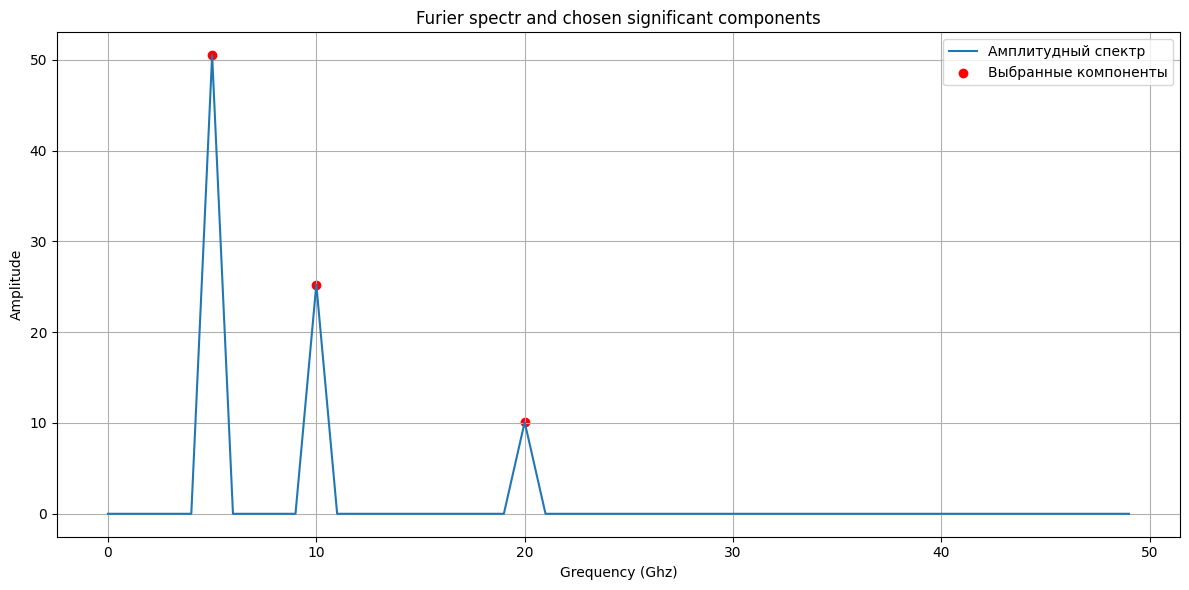

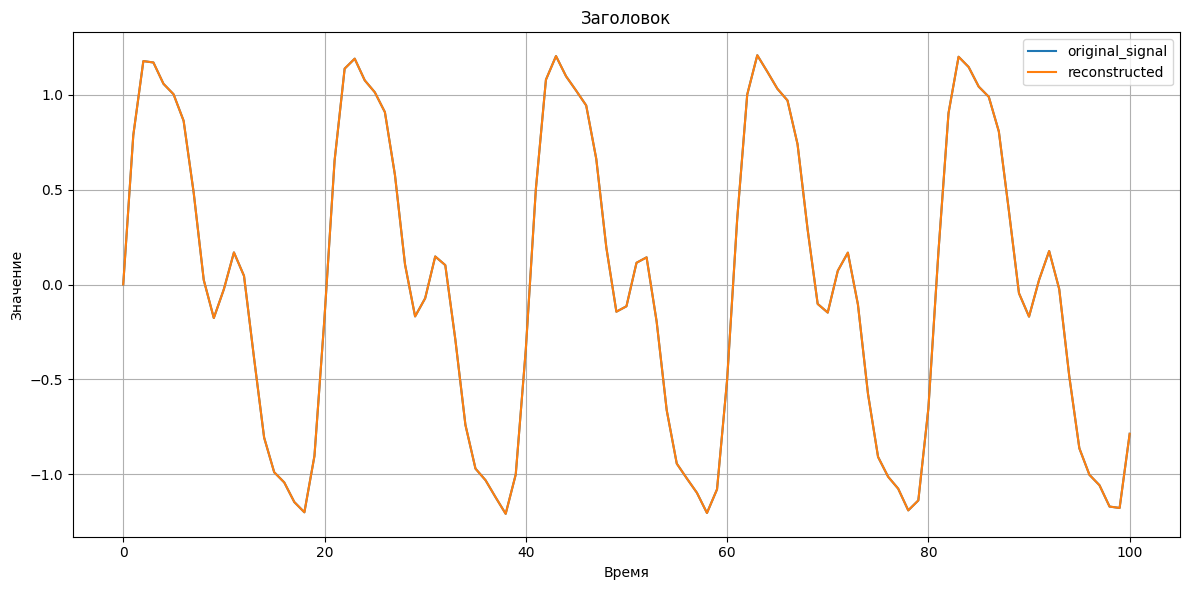

1.4932982661217763e-30


In [215]:
# Генерируем тестовый сигнал
fs = 101
t = np.linspace(0, 1, fs, endpoint=False)
original_signal = (
    np.sin(2 * np.pi * 5 * t) +
    0.5 * np.sin(2 * np.pi * 10 * t) +
    0.2 * np.sin(2 * np.pi * 20 * t)
)

# Извлечение компонент в определённом диапазоне
components, pos_comp = dft_extract(original_signal, n_freqs=3, fs=fs, freq_min=0, freq_max=None)

dft_plot(components, pos_comp[0], pos_comp[1])


# Восстановление
reconstructed = dft_aprox(components, len(original_signal), fs)

plot_series([original_signal, reconstructed],['original_signal', 'reconstructed'])

print(RMSE(original_signal, reconstructed))

In [91]:
y_train[:10]

array([0, 0, 1, 1, 0, 1, 0, 1, 1, 1])

In [86]:
dataset_name = "Chinatown" #"MelbournePedestrian"
X_train, X_test, y_train, y_test = load_data(dataset_name, 0.1, 'UCR', 'manual', 42)
print(X_train.shape, np.unique(y_train))

Old Classes: [1 2]
New Classes: [0 1]
(36, 1, 24) [0 1]


In [87]:
# def show_segments(ts_row1,ts_row2,ts_row3):
#     x_axis_1 = np.arange(len(ts_row1))  # [0, 1, 2, ..., 7]
#     x_axis_2 = np.arange(len(ts_row1), len(ts_row1) + len(ts_row2))  # [8, 9, 10, ..., 15]
#     x_axis_3 = np.arange(len(ts_row1) + len(ts_row2), len(ts_row1) + len(ts_row2) + len(ts_row3))  # [16, 17, ..., 23]

#     # Строим график
#     plt.figure(figsize=(10, 4))

#     # Отображаем каждый ряд с соответствующей осью X
#     plt.plot(x_axis_1, ts_row1, label='Segment 1', color='blue')
#     plt.plot(x_axis_2, ts_row2, label='Segment 2', color='orange')
#     plt.plot(x_axis_3, ts_row3, label='Segment 3', color='green')
#     plt.axvline(8, '-o', 'gray')
#     plt.axvline(16, '-o', 'gray')
#     plt.grid()
#     plt.show()
def show_segments(ts_row1, ts_row2, ts_row3):
    """
    Отображает три временных ряда как единое целое с разделением между сегментами.
    
    Параметры:
        ts_row1, ts_row2, ts_row3: массивы или списки - детрендированные временные ряды.
    """
    # Создаем ось X для каждого сегмента, чтобы они шли друг за другом
    x1 = np.arange(len(ts_row1))  # [0, 1, ..., len(ts_row1) - 1]
    x2 = np.arange(len(ts_row1), len(ts_row1) + len(ts_row2))
    x3 = np.arange(len(ts_row1) + len(ts_row2), 
                   len(ts_row1) + len(ts_row2) + len(ts_row3))

    # Строим график
    plt.figure(figsize=(12, 4))

    # Рисуем каждый сегмент отдельно
    plt.plot(x1, ts_row1, label='Segment 1', color='blue')
    plt.plot(x2, ts_row2, label='Segment 2', color='orange')
    plt.plot(x3, ts_row3, label='Segment 3', color='green')

    # Добавляем вертикальные пунктирные линии между сегментами
    plt.axvline(x=len(ts_row1), color='gray', linestyle='--', linewidth=1.5)
    plt.axvline(x=len(ts_row1) + len(ts_row2), color='gray', linestyle='--', linewidth=1.5)

    # Оформление графика
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()
    
    
def show_segments2(ts_row1, ts_row2, ts_row3):
    """
    Отображает три временных ряда как единое целое с разделением между сегментами.
    
    Параметры:
        ts_row1, ts_row2, ts_row3: массивы или списки - детрендированные временные ряды.
    """
    # Создаем ось X для каждого сегмента, чтобы они шли друг за другом
    x1 = np.arange(len(ts_row1[0]))  # [0, 1, ..., len(ts_row1) - 1]
    x2 = np.arange(len(ts_row1[0]), len(ts_row1[0]) + len(ts_row2[0]))
    x3 = np.arange(len(ts_row1[0]) + len(ts_row2[0]), 
                   len(ts_row1[0]) + len(ts_row2[0]) + len(ts_row3[0]))

    # Строим график
    plt.figure(figsize=(12, 4))

    # Рисуем каждый сегмент отдельно
    plt.plot(x1, ts_row1[0], color='#4682B4')
    plt.plot(x1, ts_row1[1], color='#FFA500')
    plt.plot(x2, ts_row2[0], color='#4682B4')
    plt.plot(x2, ts_row2[1], color='#FFA500')
    plt.plot(x3, ts_row3[0], color='#4682B4')
    plt.plot(x3, ts_row3[1], color='#FFA500')
    
    # Добавляем вертикальные пунктирные линии между сегментами
    plt.axvline(8, color='gray', linestyle='--', linewidth=1.5)
    plt.axvline(16, color='gray', linestyle='--', linewidth=1.5)

    # Оформление графика
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

In [91]:
# y_train[0], y_train[2]
original_row = X_train[4]
ts_row1 = tsa_detrend(original_row[:8], 1)
ts_row2 = tsa_detrend(original_row[8:16], 1)
ts_row3 = tsa_detrend(original_row[16:], 1)

fs = 100

# print(ts_row1.shape, ts_row2.shape)
comp1, pos_comp1 = dft_extract(ts_row1, 4, fs)
comp2, pos_comp2 = dft_extract(ts_row2, 4, fs)
comp3, pos_comp3 = dft_extract(ts_row3, 4, fs)

res1 = dft_aprox(comp1, ts_row1.shape[0], fs)
res2 = dft_aprox(comp2, ts_row2.shape[0], fs)
res3 = dft_aprox(comp3, ts_row3.shape[0], fs)

print('original')
# plot_series([original_row])
# print('splited original')
# show_segments(original_row, original_row[:8], original_row[8:16], original_row[16:])
show_segments(original_row[:8], original_row[8:16], original_row[16:])
print('detrended')
# show_segments(original_row, ts_row1, ts_row2, ts_row3)
show_segments(ts_row1, ts_row2, ts_row3)
print('trends')
# show_segments(original_row, original_row[:8] - ts_row1, original_row[8:16]- ts_row2, original_row[16:]- ts_row3)
show_segments(original_row[:8] - ts_row1, original_row[8:16]- ts_row2, original_row[16:]- ts_row3)
print('recon')
# show_segments(original_row, res1, res2, res3)
show_segments(res1, res2, res3)

# print(comp1, comp2)

NameError: name 'dft_extract' is not defined

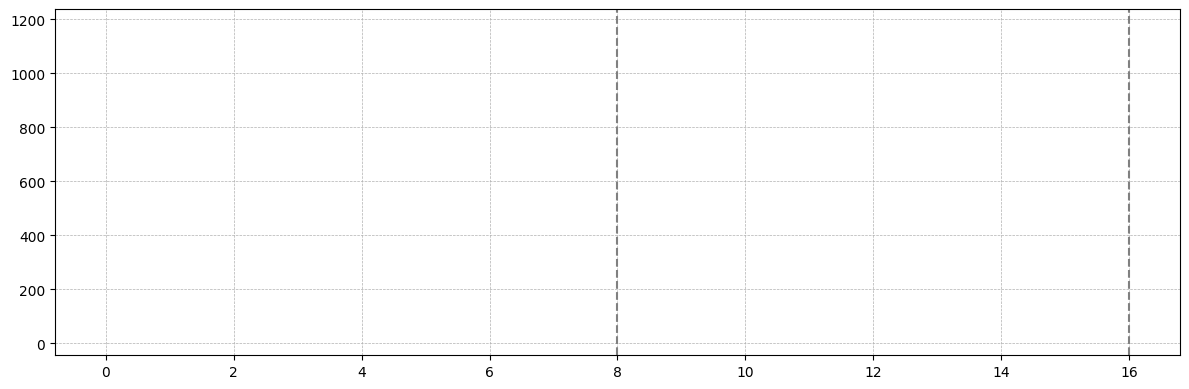

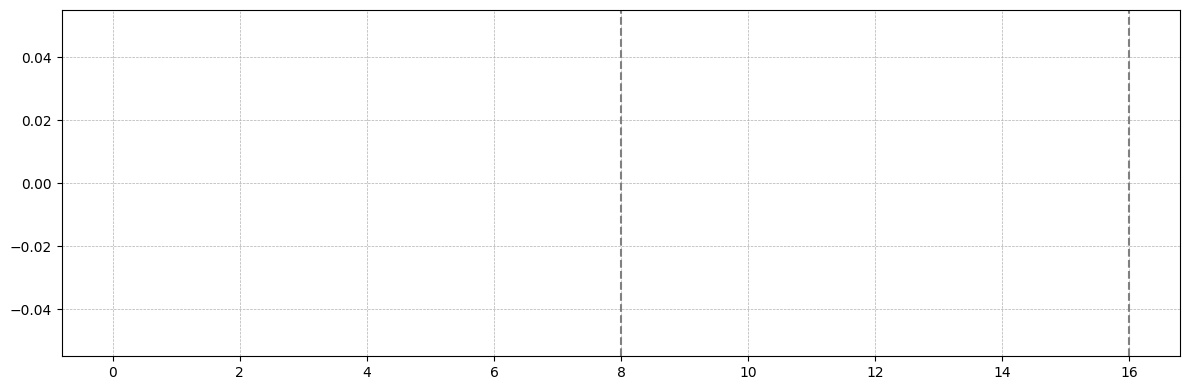

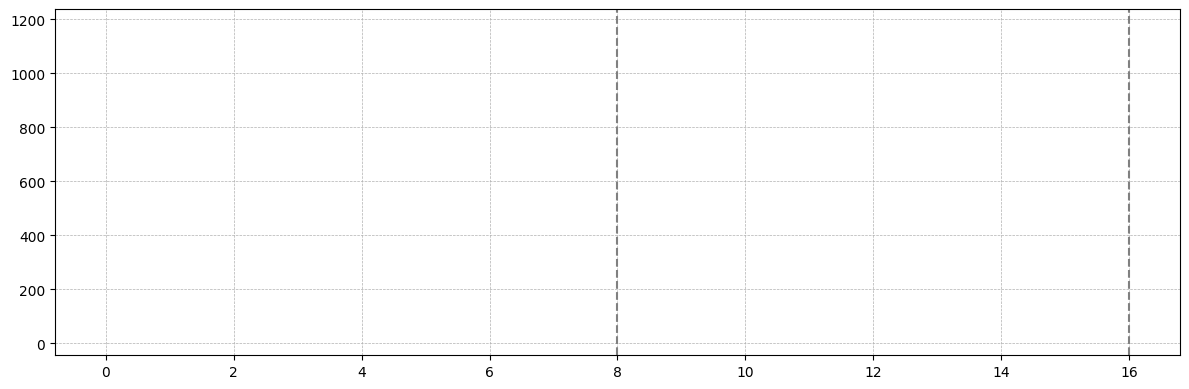

In [97]:
from src.feature_extraction.manual_methods.manual_feature_extraction import tsa_detrend
    
def show_segments2(ts_row1, ts_row2, ts_row3):
    """
    Отображает три временных ряда как единое целое с разделением между сегментами.
    
    Параметры:
        ts_row1, ts_row2, ts_row3: массивы или списки - детрендированные временные ряды.
    """
    # Создаем ось X для каждого сегмента, чтобы они шли друг за другом
    x1 = np.arange(len(ts_row1[0]))  # [0, 1, ..., len(ts_row1) - 1]
    x2 = np.arange(len(ts_row1[0]), len(ts_row1[0]) + len(ts_row2[0]))
    x3 = np.arange(len(ts_row1[0]) + len(ts_row2[0]), 
                   len(ts_row1[0]) + len(ts_row2[0]) + len(ts_row3[0]))

    # Строим график
    plt.figure(figsize=(12, 4))

    # Рисуем каждый сегмент отдельно
    plt.plot(x1, ts_row1[0], color='#4682B4')
    plt.plot(x1, ts_row1[1], color='#FFA500')
    plt.plot(x2, ts_row2[0], color='#4682B4')
    plt.plot(x2, ts_row2[1], color='#FFA500')
    plt.plot(x3, ts_row3[0], color='#4682B4')
    plt.plot(x3, ts_row3[1], color='#FFA500')
    
    # Добавляем вертикальные пунктирные линии между сегментами
    plt.axvline(8, color='gray', linestyle='--', linewidth=1.5)
    plt.axvline(16, color='gray', linestyle='--', linewidth=1.5)

    # Оформление графика
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

original_row1 = X_train[4]
ts_row11 = tsa_detrend(original_row1[:8], 1)
ts_row12 = tsa_detrend(original_row1[8:16], 1)
ts_row13 = tsa_detrend(original_row1[16:], 1)
original_row2 = X_train[3]
ts_row21 = tsa_detrend(original_row2[:8], 1)
ts_row22 = tsa_detrend(original_row2[8:16], 1)
ts_row23 = tsa_detrend(original_row2[16:], 1)

show_segments2([original_row1[:8], original_row2[:8]], [original_row1[8:16], original_row2[8:16]], [original_row1[16:], original_row2[16:]])

show_segments2([ts_row11, ts_row21], [ts_row12, ts_row22], [ts_row13, ts_row23])
show_segments2([original_row1[:8] - ts_row11, original_row2[:8] - ts_row21], [original_row1[8:16] - ts_row12, original_row2[8:16] - ts_row22], [original_row1[16:] - ts_row13, original_row2[16:] - ts_row23])

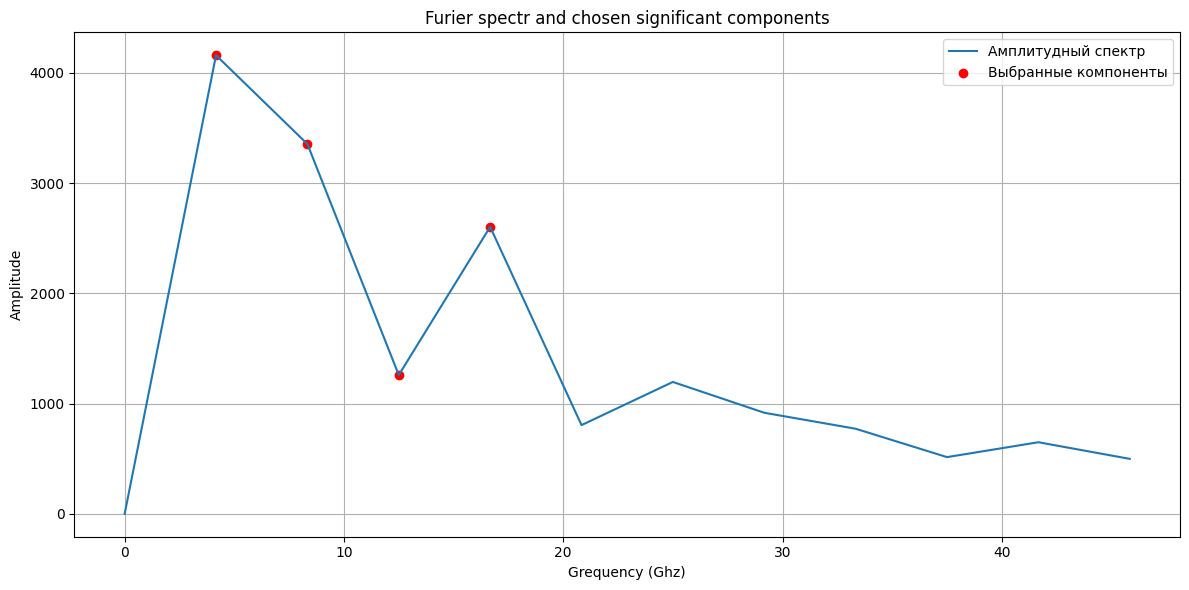

In [119]:
dft_plot(comp1, pos_comp1[0], pos_comp1[1])

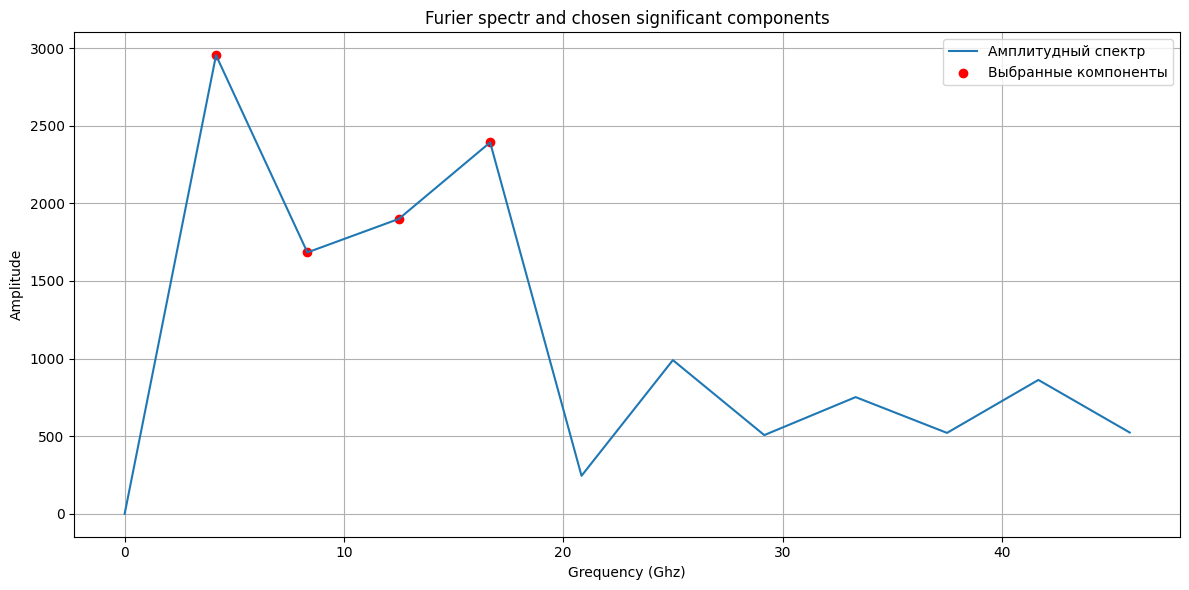

In [120]:
dft_plot(comp2, pos_comp2[0], pos_comp2[1])

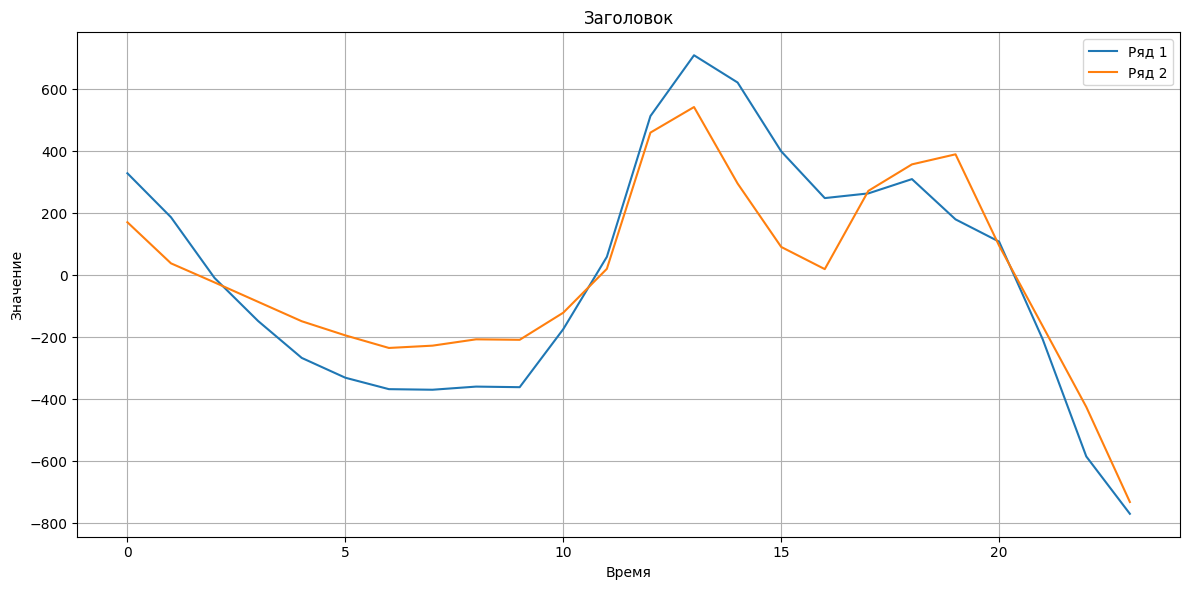

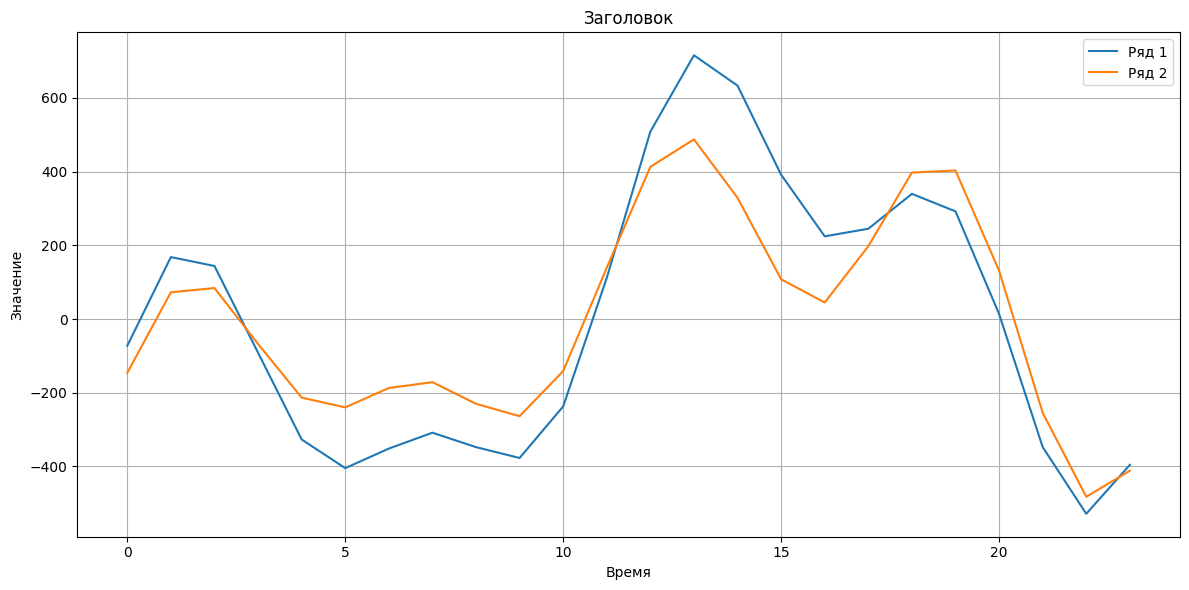

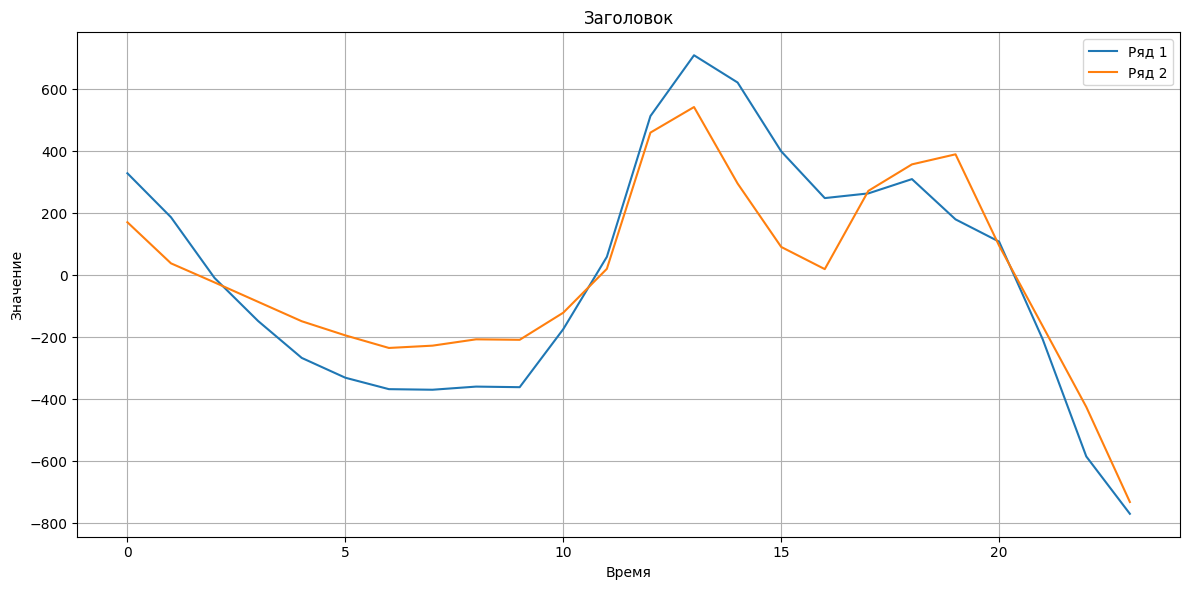

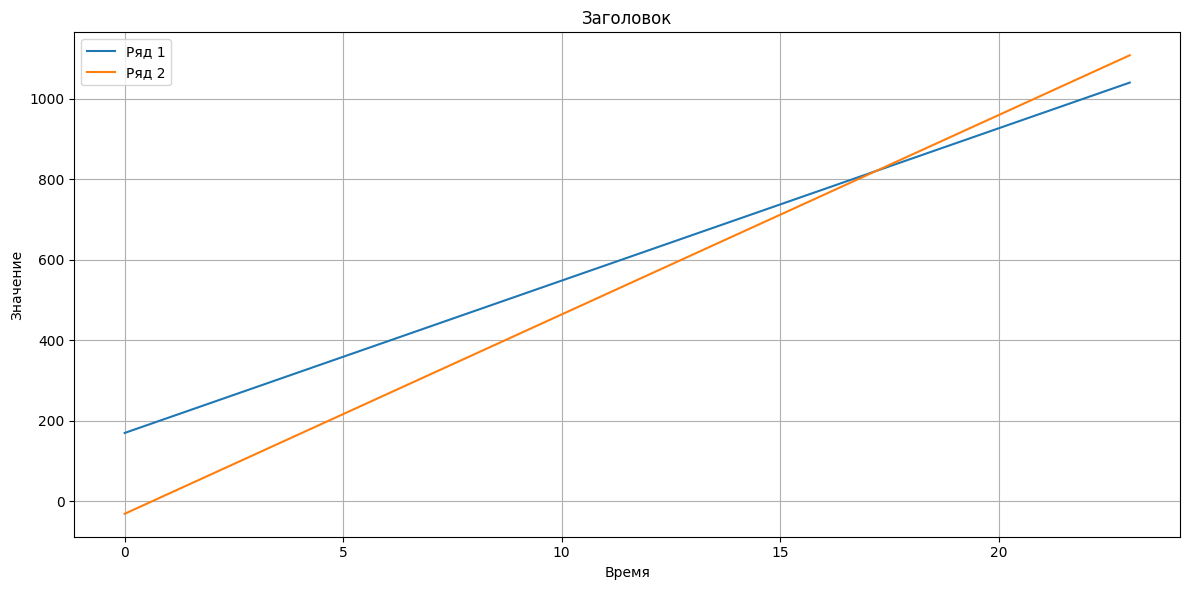

In [102]:
# y_train[0], y_train[2]
ts_row1 = tsa_detrend(X_train[4], 1)
# ts_row12 = tsa_detrend(X_train[4][12:], 1)
ts_row2 = tsa_detrend(X_train[3], 1)
# ts_row22 = tsa_detrend(X_train[3][12:], 1)
fs = 100

comp1, pos_comp1 = dft_extract(ts_row1, 4, fs)
# comp12, pos_comp12 = dft_extract(ts_row12, 2, fs)
# comp21, pos_comp21 = dft_extract(ts_row21, 2, fs)
comp2, pos_comp2 = dft_extract(ts_row2, 4, fs)

res1 = dft_aprox(comp1, ts_row1.shape[0], fs)
# res12 = dft_aprox(comp12, ts_row12.shape[0], fs)

res2 = dft_aprox(comp2, ts_row2.shape[0], fs)
# res22 = dft_aprox(comp22, ts_row22.shape[0], fs)

plot_series([ts_row1, ts_row2])
plot_series([res1, res2])
plot_series([ts_row1, ts_row2])
plot_series([X_train[4] - ts_row1, X_train[3] - ts_row2])

# print(comp1, comp2)

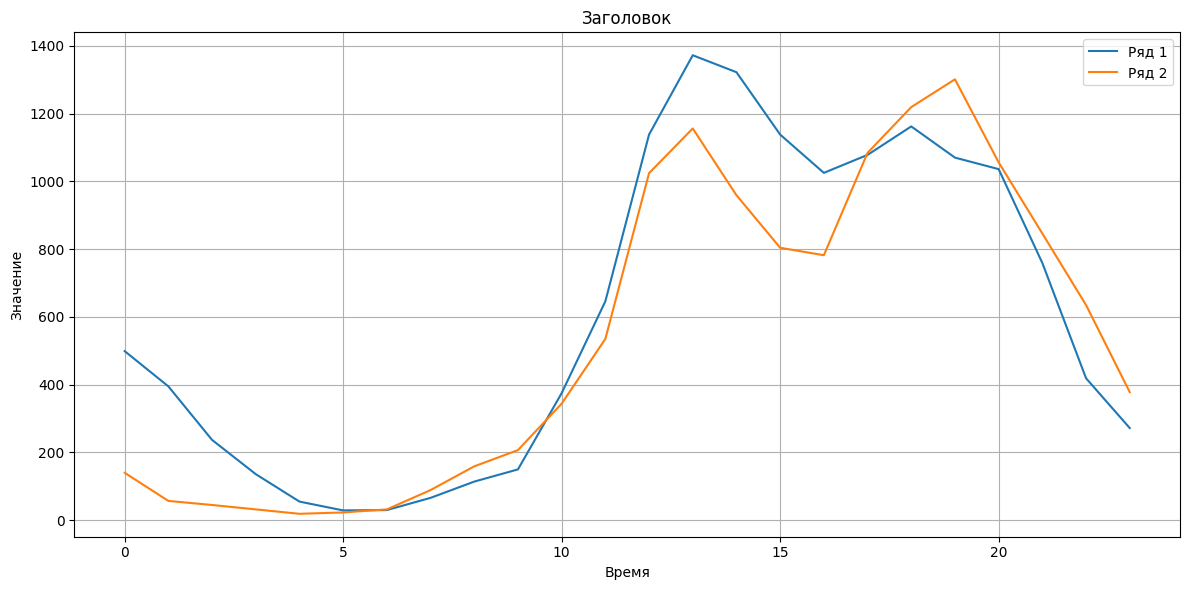

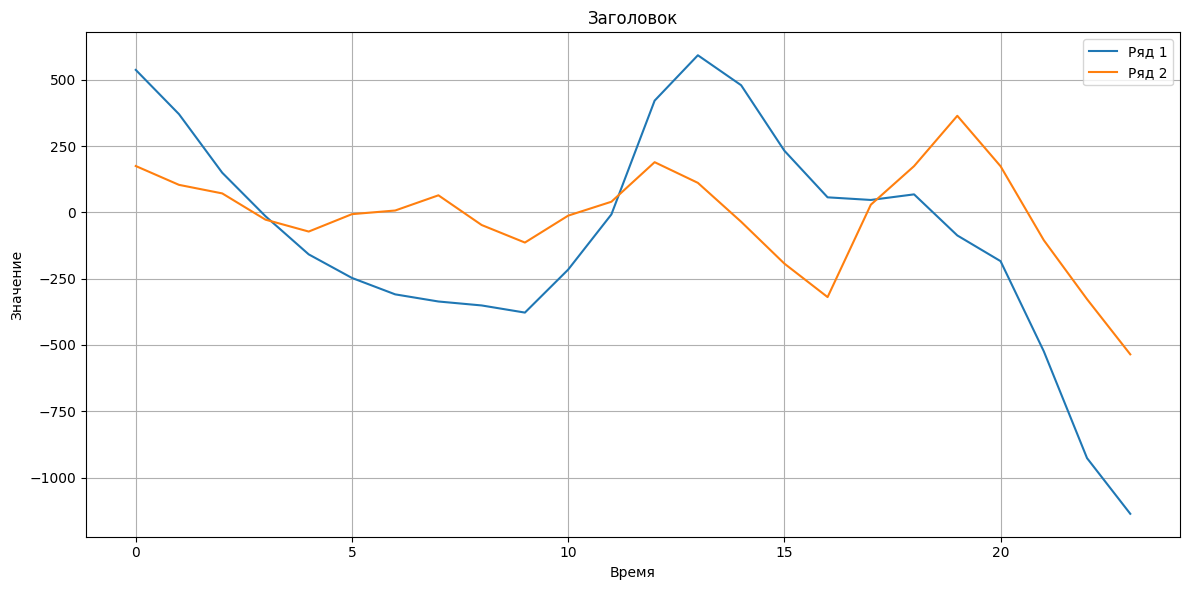

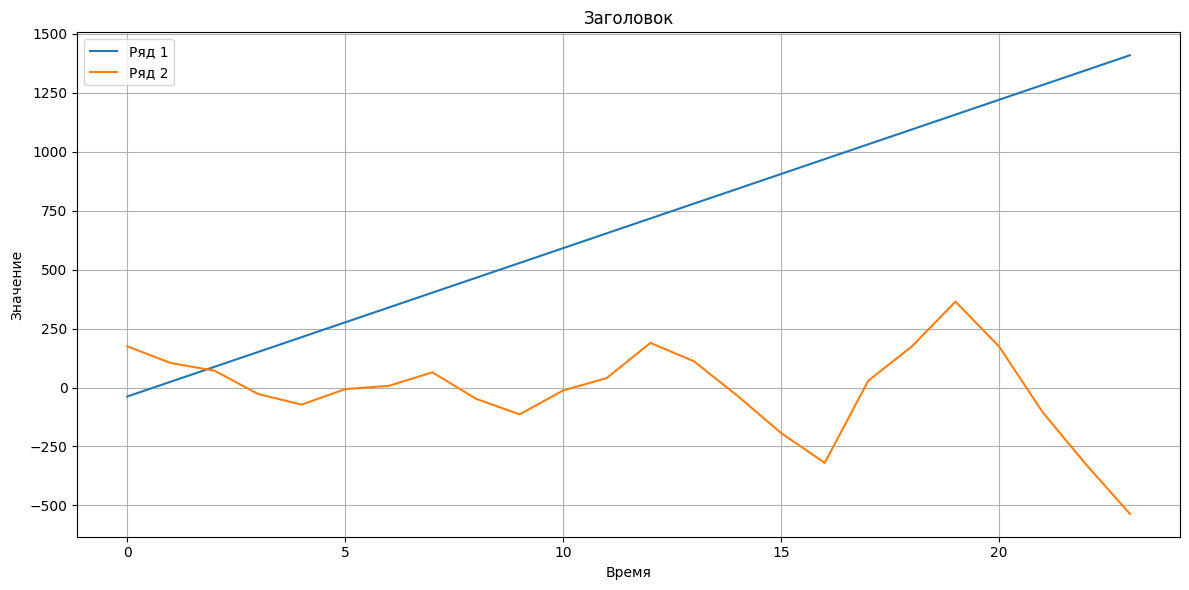

In [117]:
# y_train[0], y_train[2]
ts_row1 = X_train[4]
ts_row2 = X_train[3]

res1 = stl_decomposition(ts_row1, 12)
res2 = stl_decomposition(ts_row2, 7)

plot_series([ts_row1, ts_row2])

# plot_series([np.sum(res1, axis=0), np.sum(res2, axis=0)])
plot_series([res1[1], res2[1]])
plot_series([res1[0], res2[1]])


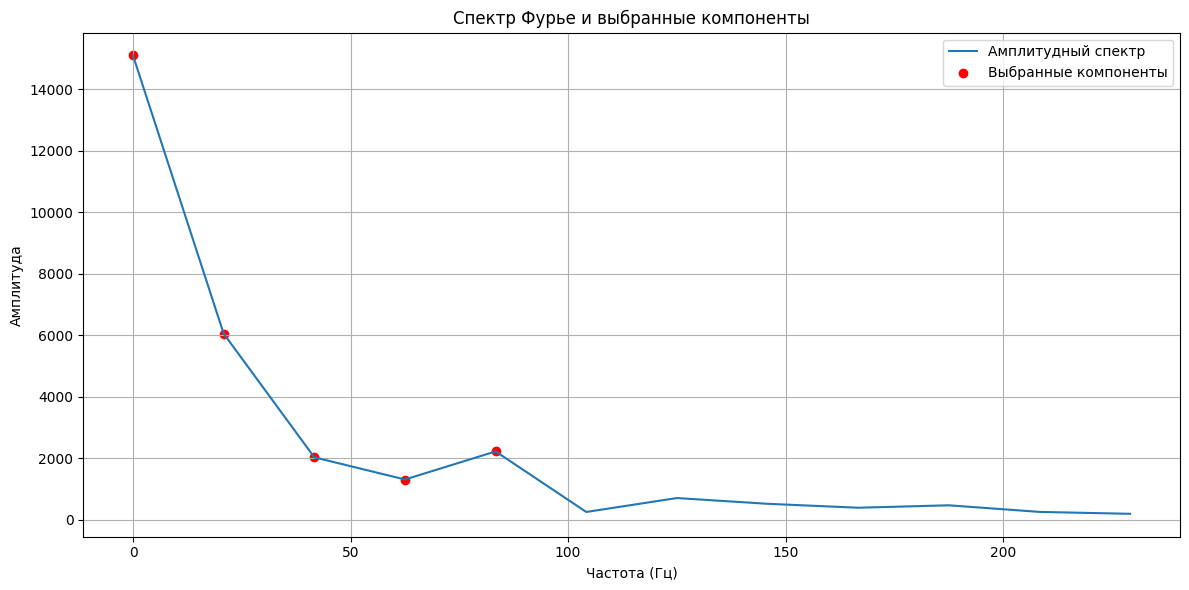

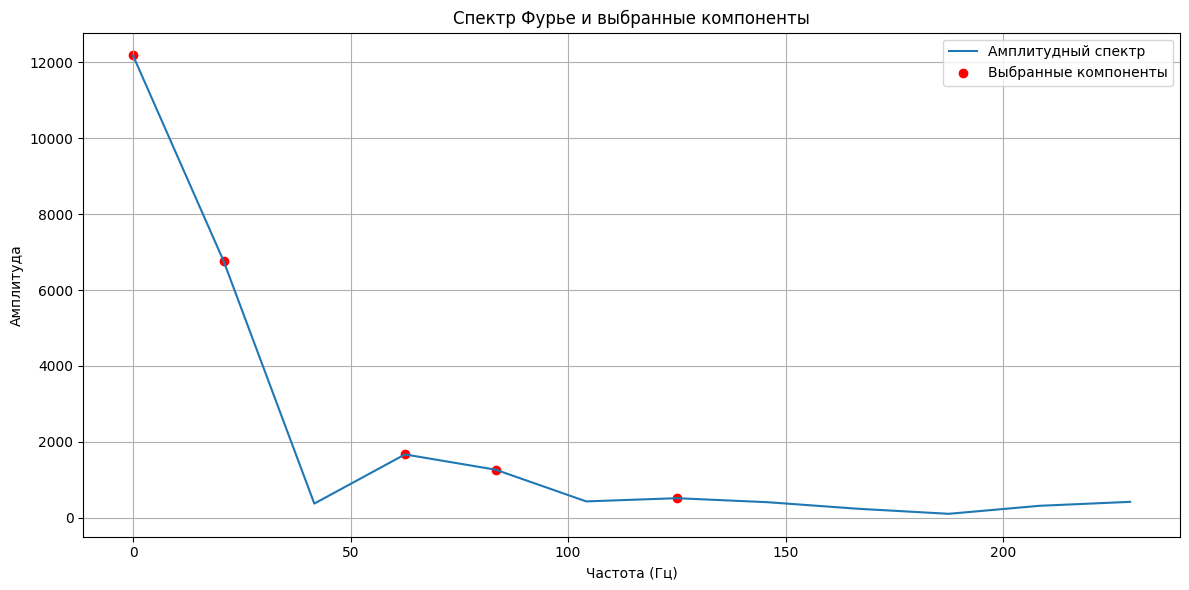

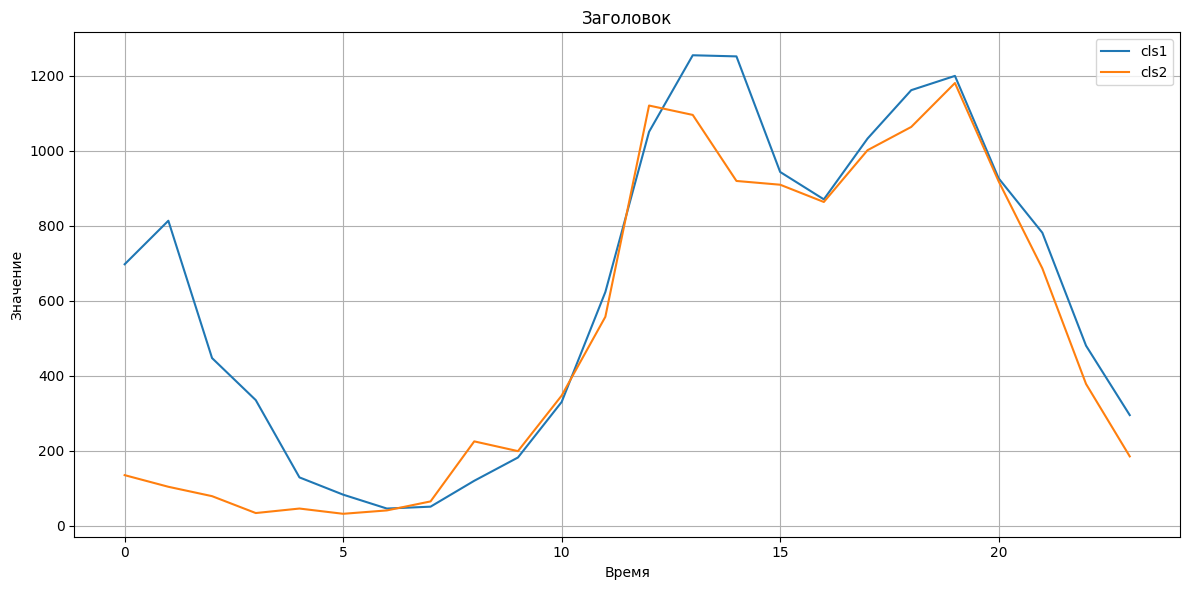

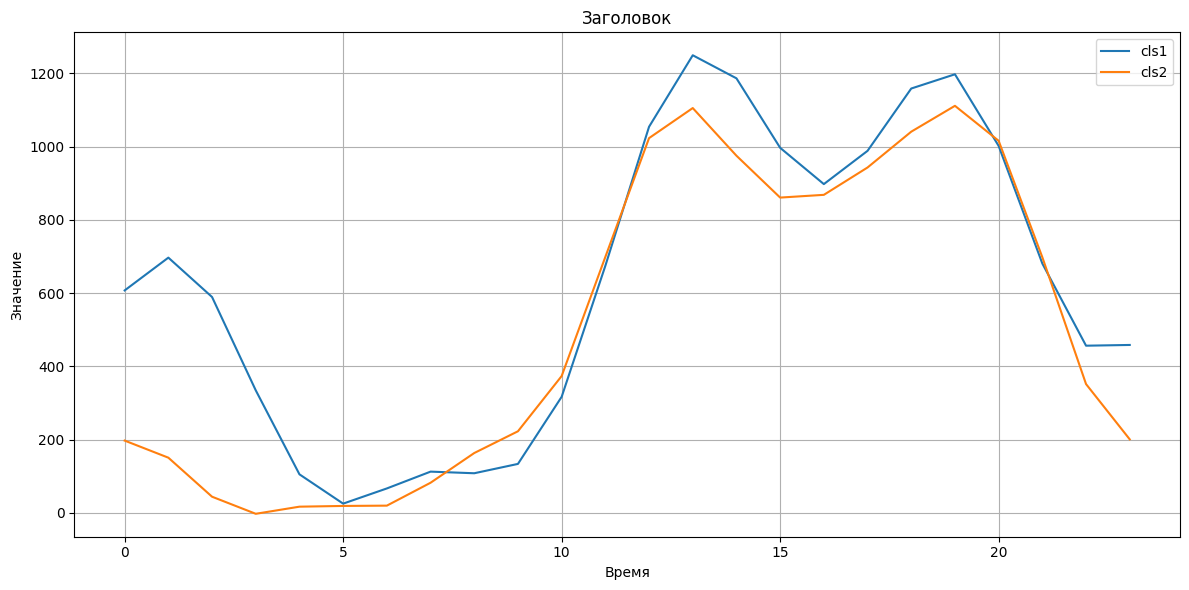

In [ ]:
fs=500
ts_row1 = real_series11 
ts_row2 = real_series12

result1, pos_comp1 = dft_extract(ts_row1, 5)
result2, pos_comp2 = dft_extract(ts_row2, 5)
dft_plot(result1, pos_comp1[0], pos_comp1[1])
dft_plot(result2, pos_comp2[0], pos_comp2[1])
# Восстановление
recon1 = dft_aprox(result1, len(ts_row1), fs)
recon2 = dft_aprox(result2, len(ts_row2), fs)

plot_series([ts_row1, ts_row2], ['cls1','cls2'])
plot_series([recon1, recon2], ['cls1','cls2'])
# plot_series([ts_row-reconstructed, trend_series1])

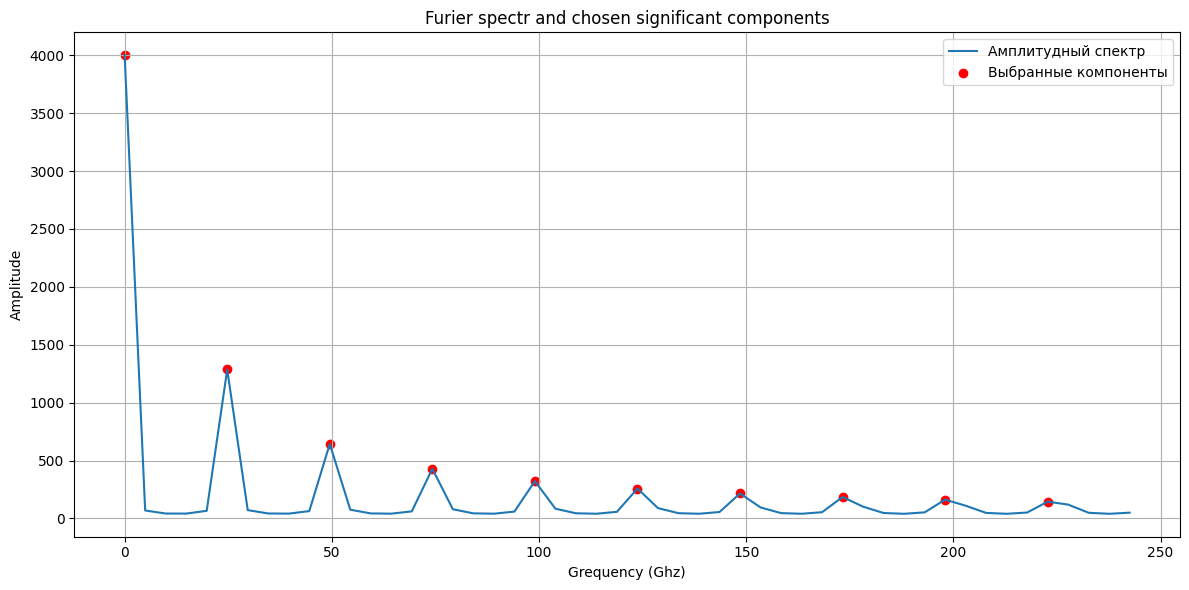

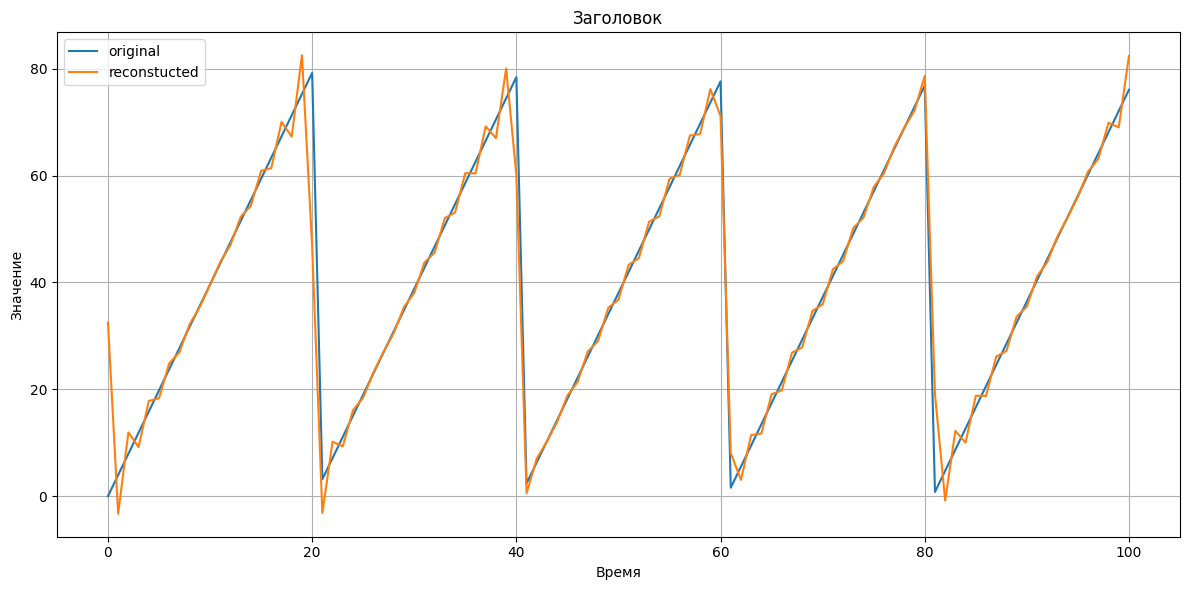

In [207]:
fs=500
# ts_row = seas_series1
ts_row = seas_series2
# ts_row = seas_series1+seas_series2
# ts_row = trend_series3+seas_series1

result, pos_comp = dft_extract(ts_row, 10)
dft_plot(result, pos_comp[0],pos_comp[1])

# Восстановление
reconstructed = dft_aprox(result, len(ts_row), fs)

plot_series([ts_row, reconstructed], ['original', 'reconstucted'])

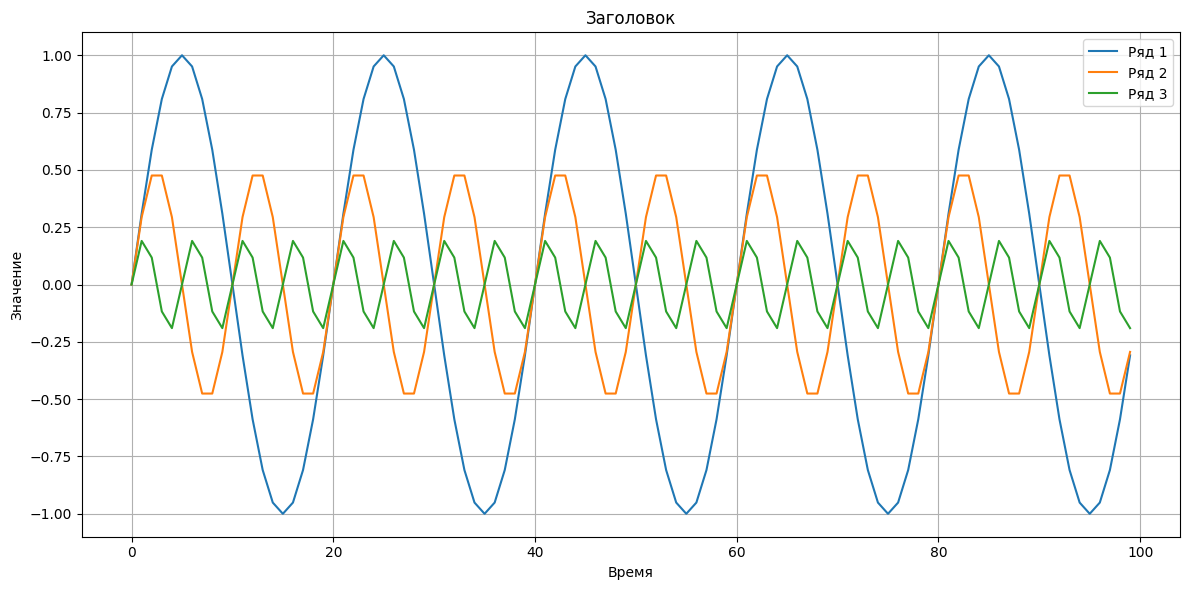

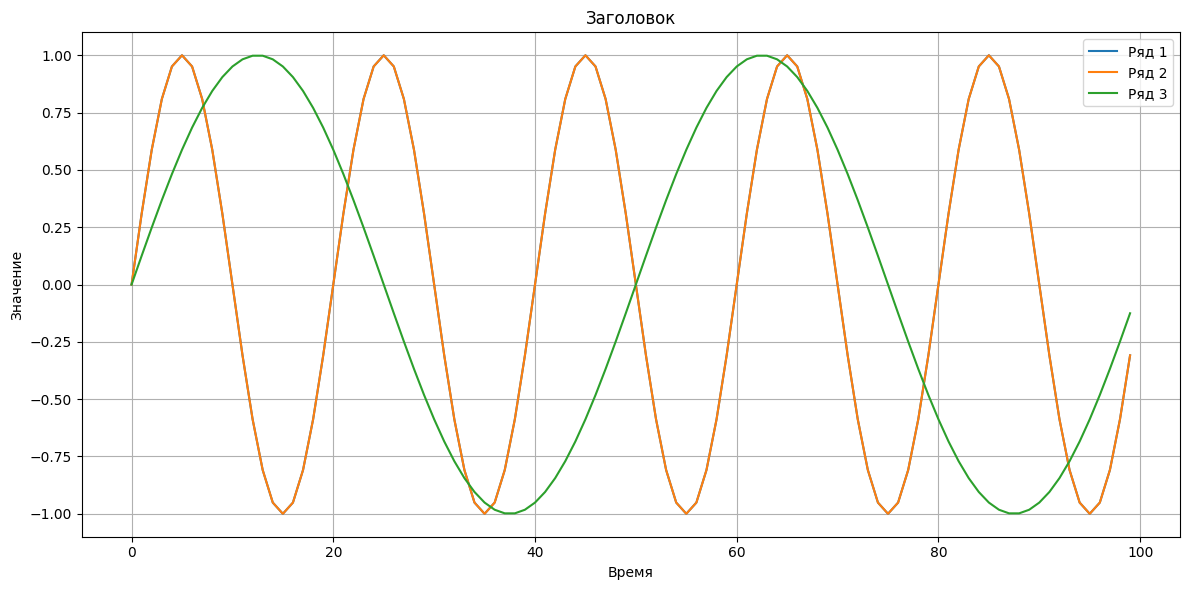

In [ ]:
fs = 100        # 100 отсчётов в секунду
t = np.linspace(0, 1, fs, endpoint=False)

signal1 = np.sin(2 * np.pi * 5 * t)
signal2 = 0.5 * np.sin(2 * np.pi * 10 * t)
signal3 = 0.2 * np.sin(2 * np.pi * 20 * t)

plot_series([signal1,signal2,signal3])

comp1, pos1 = dft_extract(signal1, 2, 5)
comp2, pos2 = dft_extract(signal1, 2, 10)

plot_series([signal1, dft_aprox(comp1, 100, 5),dft_aprox(comp1, 100, 10)])

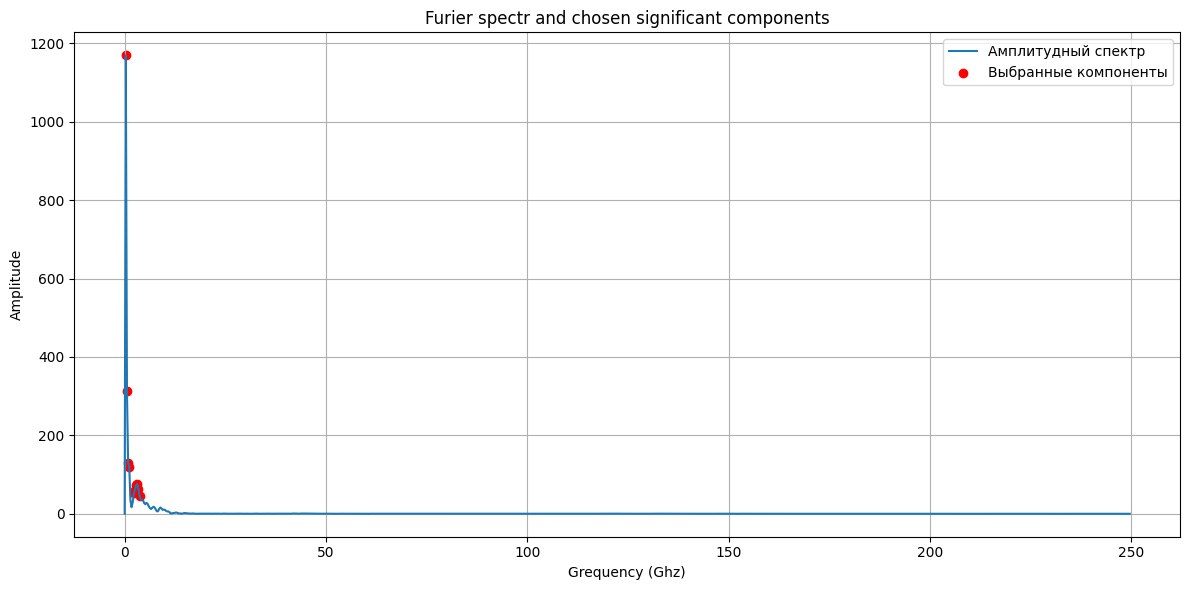

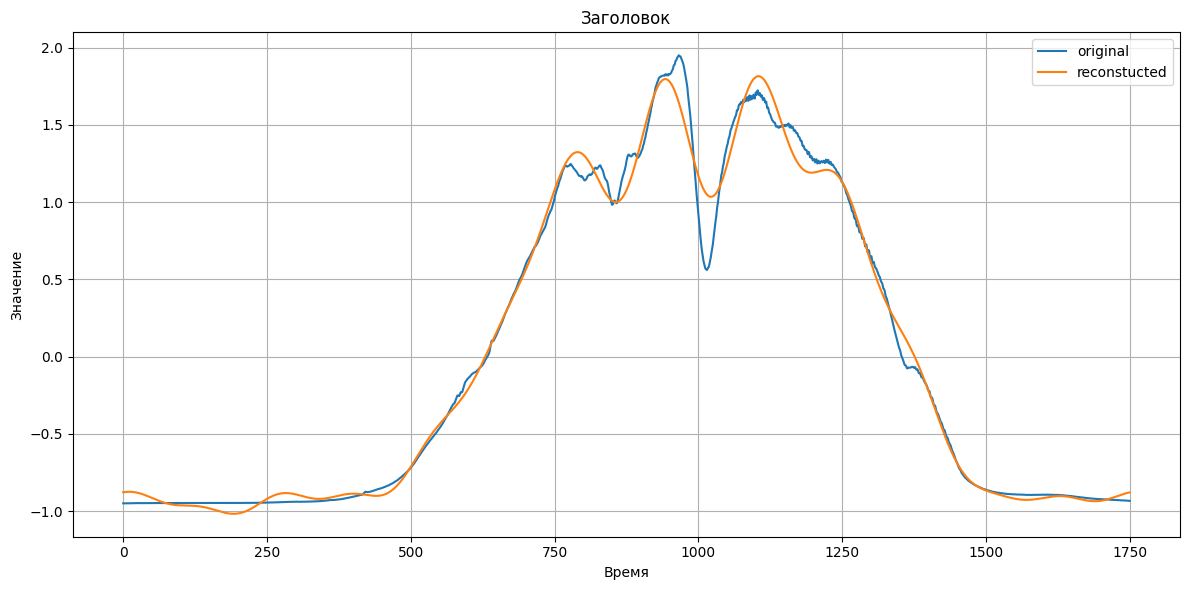

In [218]:
fs=500
ts_row = real_series21

result, pos_comp = dft_extract(ts_row, 10)
dft_plot(result, pos_comp[0],pos_comp[1])

# Восстановление
reconstructed = dft_aprox(result, len(ts_row), fs)

plot_series([ts_row, reconstructed], ['original', 'reconstucted'])

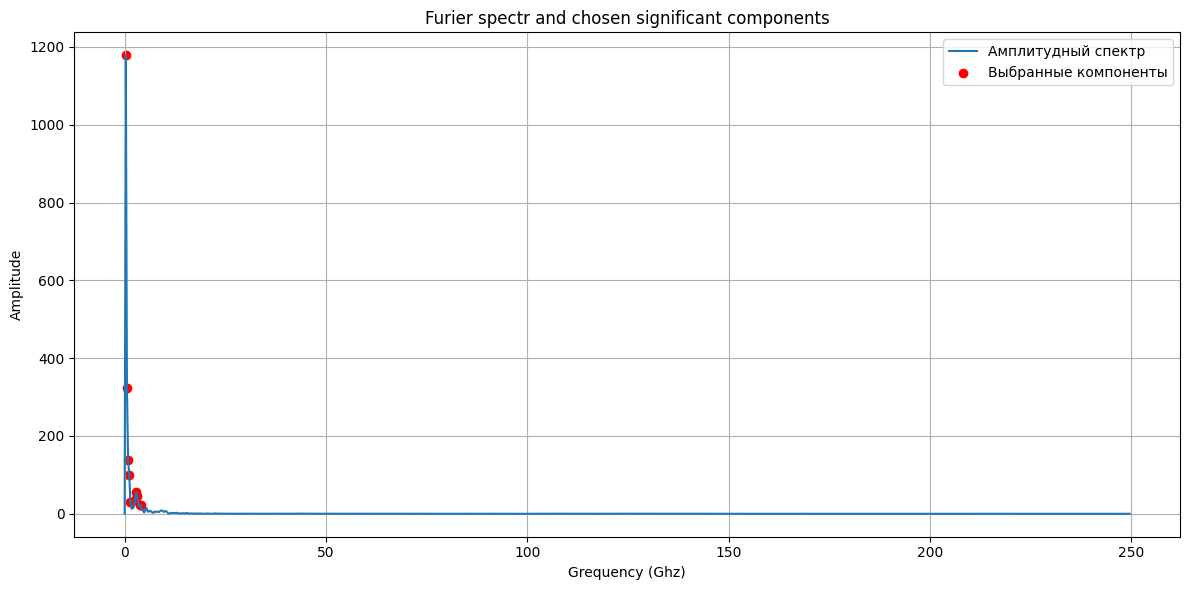

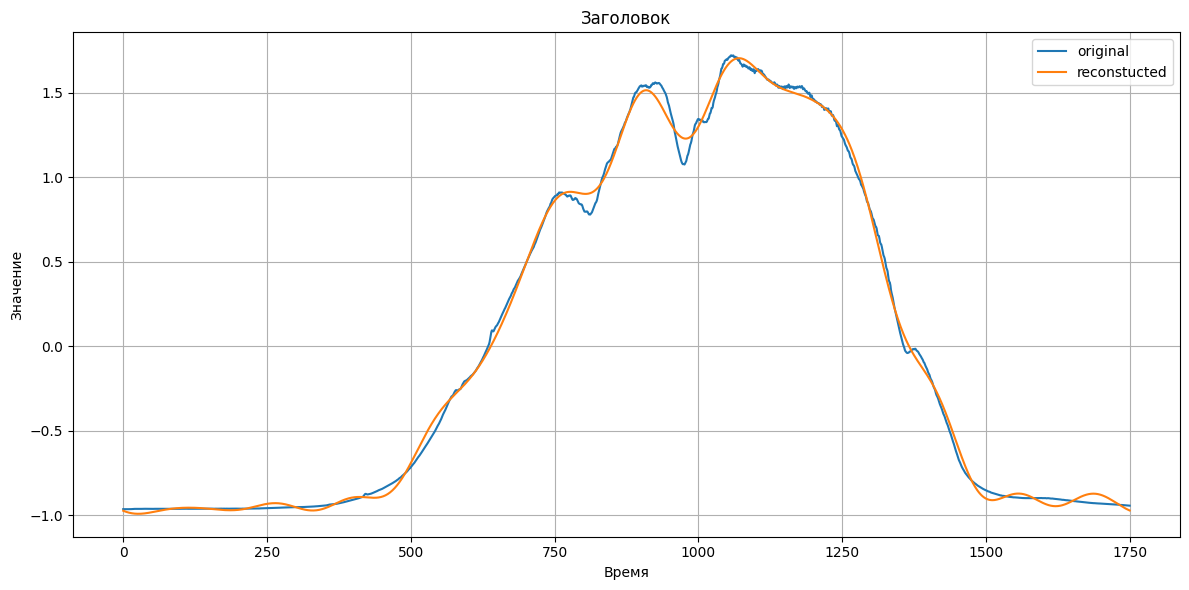

In [219]:
fs=500
ts_row = real_series22

result, pos_comp = dft_extract(ts_row, 10)
dft_plot(result, pos_comp[0],pos_comp[1])

# Восстановление
reconstructed = dft_aprox(result, len(ts_row), fs)

plot_series([ts_row, reconstructed], ['original', 'reconstucted'])